#**1) SANKEY PLOT USING G (VARIANCE GRAPH)**

### **Libraries**

In [1]:
pip install hdbscan umap-learn


In [2]:
pip install umap-learn

In [3]:
pip install networkx pandas numpy scipy scikit-learn GraphRicciCurvature


In [4]:
pip install leidenalg

In [5]:
pip install graphtools

In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import leidenalg
import igraph as ig
import plotly.graph_objects as get_ipython
from colorsys import hls_to_rgb
import plotly.graph_objects as go


## **Import data**

Load the gene interaction data, compute variance across samples for each row (interaction), sort it, and keep only the top 10% most variable edges.
(PLOT SU R)


In [7]:
df = pd.read_csv("labeled_lioness_data.csv")
df['Row_Variance'] = df.iloc[:,2:].var(axis=1)
df_sorted = df.sort_values(by="Row_Variance", ascending = False)
top_10_percent = df_sorted.iloc[:int(len(df_sorted)*0.1)]


## **Thresholds**

Define quantile thresholds to progressively remove lower variance edges. Each threshold corresponds to a sparsification level.

In [9]:
quantile_levels = [0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.97, 0.98]
quantiles = [top_10_percent['Row_Variance'].quantile(q) for q in quantile_levels]
threshold_labels = [f"Q{int(q*1000)/10}" for q in quantile_levels]

## **Leiden Clustering**

For each threshold, construct a weighted undirected graph using high-variance edges, apply Leiden clustering, and save the gene-to-cluster assignments.

In [10]:
import random

# Seed to fix the results of clustering
random_seed = 42
random.seed(random_seed)

gene_cluster_map = {}  # {soglia_label: {gene: cluster_id}}

for i, threshold in enumerate(quantiles):
  label = threshold_labels[i]
  filtered_df = top_10_percent[top_10_percent['Row_Variance'] >= threshold]


  G_nx = nx.Graph()
  for _, row in filtered_df.iterrows():
    G_nx.add_edge(row['tf'], row['gene'], weight = row['Row_Variance'])

  edges = [(u,v, float(d['weight'])) for u,v,d in G_nx.edges(data=True)]
  G_ig = ig.Graph.TupleList(edges, edge_attrs=['weight'])

  partition = leidenalg.find_partition(G_ig, leidenalg.RBConfigurationVertexPartition, weights='weight')

  cluster_map = {}
  for cluster_id, cluster in enumerate(partition):
    for idx in cluster:
        gene = G_ig.vs[idx]['name']
        cluster_map[gene] = cluster_id
  gene_cluster_map[label] = cluster_map

In [11]:
from IPython.display import Markdown

Markdown(r"""
The `leidenalg.RBConfigurationVertexPartition` class optimizes community structure using the Reichardt-Bornholdt (RB) configuration model, which generalizes modularity by introducing a resolution parameter $\gamma$. The algorithm aims to maximize the quality function:

$$
Q = \sum_{c}(e_{cc} - \gamma a_c^2)
$$

where $e_{cc}$ is the fraction of total edge weight within community $c$, and $a_c$ is the fraction of total edge weight connected to nodes in $c$. This allows for control over the granularity of detected communities. During optimization, Leiden improves the partition by locally moving nodes, refining disconnected components, and aggregating communities into super-nodes, repeating the process iteratively until convergence.
""")



The `leidenalg.RBConfigurationVertexPartition` class optimizes community structure using the Reichardt-Bornholdt (RB) configuration model, which generalizes modularity by introducing a resolution parameter $\gamma$. The algorithm aims to maximize the quality function:

$$
Q = \sum_{c}(e_{cc} - \gamma a_c^2)
$$

where $e_{cc}$ is the fraction of total edge weight within community $c$, and $a_c$ is the fraction of total edge weight connected to nodes in $c$. This allows for control over the granularity of detected communities. During optimization, Leiden improves the partition by locally moving nodes, refining disconnected components, and aggregating communities into super-nodes, repeating the process iteratively until convergence.


## **Labels and colors**

Generate human-readable labels for each cluster at each threshold and assign them distinct colors for visualization.

In [12]:
  distinct_colors = [
    "rgb(230, 25, 75)",    # rosso
    "rgb(60, 180, 75)",    # verde
    "rgb(255, 225, 25)",   # giallo
    "rgb(0, 130, 200)",    # blu
    "rgb(245, 130, 48)",   # arancione
    "rgb(145, 30, 180)",   # viola
    "rgb(70, 240, 240)",   # ciano
    "rgb(240, 50, 230)",   # rosa
    "rgb(210, 245, 60)",   # lime
    "rgb(250, 190, 190)",  # rosa chiaro
    "rgb(0, 128, 128)",    # teal
    "rgb(230, 190, 255)",  # lilla chiaro
    "rgb(170, 110, 40)",   # marrone
    "rgb(255, 250, 200)",  # giallo chiaro
    "rgb(128, 0, 0)",      # bordeaux
    "rgb(170, 255, 195)",  # verde chiaro
    "rgb(0, 0, 128)",      # blu scuro
    "rgb(128, 128, 0)",    # oliva
    "rgb(255, 215, 180)",  # pesca
    "rgb(128, 64, 0)",     # marrone scuro
    "rgb(255, 100, 255)"   # magenta
]

In [13]:
labels = []
label_index = {}
cluster_colors = {}
idx = 0
color_idx = 0

for thresh in threshold_labels:
  clusters = sorted(set(gene_cluster_map[thresh].values()))
  for cluster_id in clusters:
    label = f"{thresh}_C{cluster_id}"
    labels.append(label)
    label_index[(thresh, cluster_id)] = idx
    cluster_colors[(thresh, cluster_id)] = distinct_colors[color_idx % len(distinct_colors)]
    idx +=1
    color_idx +=1

Track gene transitions between clusters across successive thresholds to define Sankey flow paths.

In [14]:
sources, targets, values, link_colors = [],[],[],[]

for i in range(len(threshold_labels) - 1):
  t1, t2 = threshold_labels[i], threshold_labels[i+1]
  m1, m2 = gene_cluster_map[t1], gene_cluster_map[t2]

  for gene in set(m1.keys()).intersection(m2.keys()):
    c1, c2 = m1[gene], m2[gene]
    src_idx = label_index[(t1,c1)]
    tgt_idx = label_index[(t2,c2)]

    sources.append(src_idx)
    targets.append(tgt_idx)
    values.append(1)

    rgb = cluster_colors[(t1,c1)]
    rgba = rgb.replace("rgb", "rgba").replace(")", ", 0.4)")
    link_colors.append(rgba)

## **Sankey Plot**

Visualize how genes move across clusters through thresholds using a Sankey plot, where nodes are cluster labels and flows represent shared genes.

In [15]:
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels,
        line=dict(color="black", width=0.5),
        color=[cluster_colors[(thresh, cid)] for thresh, cid in label_index]  # fix qui
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])


fig.update_layout(
    title_text="Cluster Evolution",
    font_size=12,
    width=1200,
    height=800,
    plot_bgcolor="white",
    title_x=0.5
)

fig.show()

***Sistemo etichette***

In [16]:
import plotly.graph_objects as go

# Colori distinti per cluster
distinct_colors = [
    "rgb(230, 25, 75)",    # rosso
    "rgb(60, 180, 75)",    # verde
    "rgb(255, 225, 25)",   # giallo
    "rgb(0, 130, 200)",    # blu
    "rgb(245, 130, 48)",   # arancione
    "rgb(145, 30, 180)",   # viola
    "rgb(70, 240, 240)",   # ciano
    "rgb(240, 50, 230)",   # rosa
    "rgb(210, 245, 60)",   # lime
    "rgb(250, 190, 190)",  # rosa chiaro
    "rgb(0, 128, 128)",    # teal
    "rgb(230, 190, 255)",  # lilla chiaro
    "rgb(170, 110, 40)",   # marrone
    "rgb(255, 250, 200)",  # giallo chiaro
    "rgb(128, 0, 0)",      # bordeaux
    "rgb(170, 255, 195)",  # verde chiaro
    "rgb(0, 0, 128)",      # blu scuro
    "rgb(128, 128, 0)",    # oliva
    "rgb(255, 215, 180)",  # pesca
    "rgb(128, 64, 0)",     # marrone scuro
    "rgb(255, 100, 255)"   # magenta
]

# Inizializzazione
labels = []
label_index = {}
cluster_colors = {}
idx = 0
color_idx = 0

# Costruisci etichette con formato Q0.25_C0
for thresh in threshold_labels:
    clusters = sorted(set(gene_cluster_map[thresh].values()))
    thresh_float = float(str(thresh).replace("Q", "")) / 100
    for cluster_id in clusters:
        label = f"Q{thresh_float:.2f}_C{cluster_id}"
        labels.append(label)
        label_index[(thresh, cluster_id)] = idx
        cluster_colors[(thresh, cluster_id)] = distinct_colors[color_idx % len(distinct_colors)]
        idx += 1
        color_idx += 1

# Traccia transizioni tra soglie
sources, targets, values, link_colors = [], [], [], []

for i in range(len(threshold_labels) - 1):
    t1, t2 = threshold_labels[i], threshold_labels[i + 1]
    m1, m2 = gene_cluster_map[t1], gene_cluster_map[t2]

    for gene in set(m1.keys()).intersection(m2.keys()):
        c1, c2 = m1[gene], m2[gene]
        src_idx = label_index[(t1, c1)]
        tgt_idx = label_index[(t2, c2)]

        sources.append(src_idx)
        targets.append(tgt_idx)
        values.append(1)

        rgb = cluster_colors[(t1, c1)]
        rgba = rgb.replace("rgb", "rgba").replace(")", ", 0.4)")
        link_colors.append(rgba)

# Crea Sankey Plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels,
        line=dict(color="black", width=0.5),
        color=[cluster_colors[(thresh, cid)] for thresh, cid in label_index]
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Cluster Evolution Across Thresholds",
    font_size=12,
    width=1200,
    height=800,
    plot_bgcolor="white",
    title_x=0.5
)

fig.show()


*A Sankey plot combined with Leiden clustering on a graph of variances G is an effective tool for identifying "hotzones" in complex data networks. Initially, the graph includes all edges, even those with low variance, meaning that it represents a broad, unrefined network. As the graph is sparsified by gradually removing edges with low variance, it becomes increasingly focused on the most variable interactions — those edges that have a high degree of fluctuation or change. This filtering process allows the graph to highlight key nodes and clusters where variability is most pronounced, revealing areas of the network (referred to as "hotzones") that exhibit dynamic behavior or unusual patterns.*

*Leiden clustering, applied after the sparsification, groups nodes into communities based on the strength and similarity of their interactions, but with a particular emphasis on the most variable connections. By leveraging both the variance of edges and the clustering approach, this method provides a more nuanced and targeted view of the network, helping to uncover regions of the graph that may be driving key biological or systemic processes.*

Compute average variance of edges connected to genes in each cluster at each threshold. High values indicate dynamic activity ("hotness")

In [17]:
from collections import defaultdict

# Compute the average variance for each cluster at each threshold
cluster_variances = defaultdict(dict)

for threshold in threshold_labels:
    # Mappa gene-cluster for this threshold
    gene_cluster_map_for_threshold = gene_cluster_map[threshold]

    # For each cluster
    for cluster_id in set(gene_cluster_map_for_threshold.values()):
        # Find the genes in the cluster
        genes_in_cluster = [gene for gene, assigned_cluster in gene_cluster_map_for_threshold.items() if assigned_cluster == cluster_id]

        # ATTENZIONE: bisogna cercare sia 'tf' che 'gene' nelle colonne!
        # Perché il grafo è costruito su 'tf' e 'gene', non solo su 'gene'.
        mask = top_10_percent['tf'].isin(genes_in_cluster) | top_10_percent['gene'].isin(genes_in_cluster)
        cluster_variance_values = top_10_percent[mask]['Row_Variance']


        mean_variance = cluster_variance_values.mean() if not cluster_variance_values.empty else 0


        cluster_variances[threshold][cluster_id] = mean_variance

# Print the results
for threshold in threshold_labels:
    print(f"\n🔸 Threshold {threshold}:")
    for cluster_id, mean_variance in cluster_variances[threshold].items():
        print(f"  Cluster {cluster_id}: Mean Variance = {mean_variance:.4f}")



🔸 Threshold Q0.0:
  Cluster 0: Mean Variance = 109.8078
  Cluster 1: Mean Variance = 96.1699
  Cluster 2: Mean Variance = 155.5454

🔸 Threshold Q25.0:
  Cluster 0: Mean Variance = 112.7652
  Cluster 1: Mean Variance = 94.5996
  Cluster 2: Mean Variance = 117.5959

🔸 Threshold Q50.0:
  Cluster 0: Mean Variance = 107.5890
  Cluster 1: Mean Variance = 103.1482

🔸 Threshold Q75.0:
  Cluster 0: Mean Variance = 114.2752
  Cluster 1: Mean Variance = 103.7572
  Cluster 2: Mean Variance = 110.1490

🔸 Threshold Q90.0:
  Cluster 0: Mean Variance = 138.8250
  Cluster 1: Mean Variance = 142.5795
  Cluster 2: Mean Variance = 160.5372
  Cluster 3: Mean Variance = 146.9939

🔸 Threshold Q95.0:
  Cluster 0: Mean Variance = 128.5420
  Cluster 1: Mean Variance = 169.1209

🔸 Threshold Q97.0:
  Cluster 0: Mean Variance = 149.0162
  Cluster 1: Mean Variance = 140.6729
  Cluster 2: Mean Variance = 156.5257
  Cluster 3: Mean Variance = 308.4748

🔸 Threshold Q98.0:
  Cluster 0: Mean Variance = 162.1640
  Clust

**Fiedler Value**

Calculate the Fiedler value for each cluster, which quantifies how structurally connected the cluster is. Higher values mean better internal cohesion

In [18]:
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigvalsh

fiedler_values = defaultdict(dict)  # Dictionary to store Fiedler values for each cluster at each threshold

for threshold in threshold_labels:
    # Get the gene-to-cluster mapping at the current threshold
    gene_cluster_map_for_threshold = gene_cluster_map[threshold]

    # Filter the data to include only edges with Row_Variance above the current threshold
    filtered_df = top_10_percent[
        (top_10_percent['Row_Variance'] >= quantiles[threshold_labels.index(threshold)])
    ]

    for cluster_id in set(gene_cluster_map_for_threshold.values()):
        # Get all genes assigned to the current cluster
        cluster_genes = [gene for gene, cid in gene_cluster_map_for_threshold.items() if cid == cluster_id]

        # Extract only the edges where both source and target genes are in the current cluster
        cluster_edges = filtered_df[
            filtered_df['tf'].isin(cluster_genes) & filtered_df['gene'].isin(cluster_genes)
        ]

        # If the cluster is too small (less than 2 edges), assign Fiedler value = 0
        if len(cluster_edges) < 2:
            fiedler_values[threshold][cluster_id] = 0
            continue

        # Build the subgraph for the current cluster
        G_sub = nx.Graph()
        for _, row in cluster_edges.iterrows():
            G_sub.add_edge(row['tf'], row['gene'], weight=row['Row_Variance'])

        # Create the weighted adjacency matrix
        A = nx.to_numpy_array(G_sub, weight='weight')

        # Compute the normalized Laplacian matrix
        L = laplacian(A, normed=True)

        # Compute the eigenvalues of the Laplacian matrix
        eigenvalues = eigvalsh(L)

        # The Fiedler value is the second smallest eigenvalue (index 1)
        fiedler = eigenvalues[1] if len(eigenvalues) > 1 else 0
        fiedler_values[threshold][cluster_id] = fiedler


In [19]:
for threshold in threshold_labels:
    print(f"\n🔸 Threshold {threshold}:")
    for cluster_id, f_value in fiedler_values[threshold].items():
        print(f"  Cluster {cluster_id}: Fiedler value = {f_value:.4f}")



🔸 Threshold Q0.0:
  Cluster 0: Fiedler value = 0.9446
  Cluster 1: Fiedler value = 0.9039
  Cluster 2: Fiedler value = 0.5442

🔸 Threshold Q25.0:
  Cluster 0: Fiedler value = 0.9353
  Cluster 1: Fiedler value = 0.8458
  Cluster 2: Fiedler value = 0.6911

🔸 Threshold Q50.0:
  Cluster 0: Fiedler value = 0.8714
  Cluster 1: Fiedler value = 0.8964

🔸 Threshold Q75.0:
  Cluster 0: Fiedler value = 0.9457
  Cluster 1: Fiedler value = 0.7846
  Cluster 2: Fiedler value = 0.8279

🔸 Threshold Q90.0:
  Cluster 0: Fiedler value = 0.8971
  Cluster 1: Fiedler value = 0.9794
  Cluster 2: Fiedler value = 1.0000
  Cluster 3: Fiedler value = 1.0000

🔸 Threshold Q95.0:
  Cluster 0: Fiedler value = 0.8816
  Cluster 1: Fiedler value = 0.6829

🔸 Threshold Q97.0:
  Cluster 0: Fiedler value = 1.0000
  Cluster 1: Fiedler value = 1.0000
  Cluster 2: Fiedler value = 1.0000
  Cluster 3: Fiedler value = 0.3720

🔸 Threshold Q98.0:
  Cluster 0: Fiedler value = 1.0000
  Cluster 1: Fiedler value = 1.0000
  Cluster 2: 

The **Fiedler value** measures the **internal connectivity** of a cluster within a graph. A high Fiedler value (close to 1) indicates that the cluster is tightly connected and structurally cohesive, while a low value suggests weaker internal links or a more fragmented structure. Tracking Fiedler values across thresholds reveals how robust or stable clusters are as the network becomes sparser.


This pipeline identifies "hotzones" in a gene interaction network by combining:

* Edge variance filtering to isolate dynamic interactions.
* Leiden clustering to group strongly interacting genes.
* Sankey plots to track cluster evolution.
* Mean variance as a measure of biological "activity" within clusters.
* Fiedler values to evaluate structural integrity of each cluster.

By selecting clusters that are both high variance and well-connected, the approach isolates stable and dynamic regions of the network likely relevant for further biological investigation.

## **Extract the HotZone genes**

**1) ALL TOGETHER**

In [20]:
threshold_to_extract = 'Q98.0'

all_genes = list(gene_cluster_map[threshold_to_extract].keys())

print(f"All genes at threshold {threshold_to_extract}:")
print(all_genes)
print(f"Total genes: {len(all_genes)}")


All genes at threshold Q98.0:
['MAGED1', 'AIFM1', 'MAOB', 'TMSB15A', 'MAP3K15', 'SLC6A8', 'NDUFB11', 'ARHGAP6', 'GAGE12G', 'ZC3H12B', 'GAGE12D', 'RBM10', 'BEX5', 'RPS4Y1', 'ARSD', 'PDZD4', 'KIAA1210', 'RAI2', 'RAB41', 'CXorf38', 'TSPY1', 'PDZD11', 'NLGN4Y', 'FTHL17', 'KDM6A', 'ARHGEF9', 'UTY', 'NDUFA1', 'IRAK1', 'IGBP1', 'ZMAT1', 'PIGA', 'RBMY1D', 'CSAG1', 'DMD', 'NLGN4X', 'SH3KBP1', 'TMSB4X', 'PPEF1', 'MSL3', 'ZNF630', 'SASH3', 'GPM6B', 'TAF7L', 'ZFY', 'MID1IP1', 'SLC38A5', 'SLC25A14', 'ARHGAP4', 'ARHGEF6', 'KIF4A', 'HSD17B10', 'TFE3', 'NLGN3', 'PAK3', 'BTK', 'TSPAN6', 'KLHL34', 'APOOL', 'MAMLD1', 'TAF9B', 'CSTF2', 'GRIA3', 'PFKFB1', 'GABRQ', 'PCDH19', 'MBTPS2', 'MAGIX', 'CDK16', 'HS6ST2', 'DDX3X', 'UPRT', 'RAP2C', 'NUDT10', 'FAM9B', 'GAGE12B', 'ZRSR2', 'CNKSR2', 'PCDH11Y', 'GAGE12H', 'ZNF449', 'AP1S2', 'ZNF81', 'AMOT', 'PAGE2B', 'SLC25A43', 'BCORL1', 'FRMPD4', 'SCML1', 'SLC25A5', 'CLCN5', 'NHS', 'NAP1L3', 'ZXDA', 'ATRX', 'CITED1', 'UBQLN2', 'ARMCX2', 'RPL10', 'TBL1X', 'RIBC1', 'CHIC1

In [21]:
filtered_df = df[df['tf'].isin(all_genes) & df['gene'].isin(all_genes)]
filtered_df

,tf,gene,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,...,Sample_42,Sample_43,Sample_44,Sample_45,Sample_46,Sample_47,Sample_48,Sample_49,Sample_50,Row_Variance
1437,AFF2,PCDH11Y,-3.823800,0.274878,-5.975964,-0.122896,-3.550411,-0.254009,3.712125,-6.392849,...,-7.709454,-5.062950,-1.934617,-9.863098,0.934978,10.413186,-14.429083,11.549497,-0.895402,37.302398
1438,AIFM1,PCDH11Y,4.550390,6.939310,5.262910,3.470822,3.158394,4.829010,6.864064,4.993612,...,4.259091,4.532846,5.052922,5.231005,6.629819,7.291920,4.717943,5.878468,3.460698,1.541097
1441,AMOT,PCDH11Y,5.032013,6.772230,6.317274,4.539820,4.422478,5.072354,6.774531,5.911761,...,5.393000,5.063623,4.847803,6.077821,5.719351,6.545418,5.629776,5.476925,4.687925,0.515249
1442,AP1S2,PCDH11Y,4.730979,6.281401,4.110611,3.458172,3.054165,5.220190,5.820357,5.459722,...,3.661475,5.699990,3.389536,4.330135,6.286497,6.623339,5.258354,6.059470,3.042480,1.415035
1445,APOOL,PCDH11Y,-0.500162,13.195315,-2.497965,-1.781141,-1.662874,3.184926,2.146683,4.316566,...,-1.252844,9.518030,0.605693,-5.009425,-4.979824,-15.633722,15.398379,-0.049821,-2.259487,39.259680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128873,ZNF449,ARHGAP6,4.754085,5.976650,5.590506,4.254038,5.181681,5.735460,7.181166,4.961595,...,5.682279,6.451096,5.536431,4.974648,5.530314,6.750249,6.016199,4.478013,6.197411,1.010411
128874,ZNF630,ARHGAP6,-3.819820,-6.167513,-3.776926,-3.051421,-5.535428,-3.942833,-5.589027,-4.612117,...,-3.686967,-3.577675,-4.594965,-3.723477,-4.691459,-6.061626,-4.026188,-2.536798,-5.438611,1.283158
128877,ZNF81,ARHGAP6,3.902145,6.769694,5.395756,3.500334,6.369508,5.316202,6.580858,4.830704,...,4.289979,5.408933,5.846612,4.294963,4.509000,6.327082,5.701310,3.560915,4.933794,1.125033
128878,ZRSR2,ARHGAP6,4.231190,7.257740,6.482589,4.132573,5.421536,5.333749,7.202395,5.458174,...,5.742550,5.399373,5.199852,6.007216,5.094872,6.398409,5.490362,4.184571,4.915371,0.876611


In [126]:
# Salvataggio in un file CSV
filtered_df.to_csv('filtered_df.csv', index=False)

# **2) CLUSTERING CON PCA**

Hai già selezionato un insieme di interazioni gene-TF che mostrano alta variabilità. Ora vuoi capire se queste interazioni distinguono gli individui: cioè, se le persone nel dataset hanno profili diversi tra loro in termini di queste interazioni.

Per farlo, puoi considerare ogni individuo come un vettore, in cui ogni elemento è il valore di una certa interazione gene-TF.



La PCA riduce un dataset ad alta dimensionalità (es. 1000 interazioni per 50 individui) in 2 o 3 componenti principali, che rappresentano le direzioni di massima variazione nei dati.

Ogni punto nel grafico sarà un individuo.
Se i punti (individui) sono sparsi → significa che ci sono differenze tra i loro profili.
Se i punti sono accorpati → gli individui sono simili tra loro sulle interazioni che stai analizzando.

The Principal Component Analysis (PCA) is a dimensionality reduction technique that allows us to capture the maximum variability in a dataset by projecting the data onto a smaller number of components. In this case, we are interested in understanding the variability between individuals based on their gene-TF interaction profiles.

Each individual in the dataset is represented by a vector, where each element corresponds to a specific gene-TF interaction value. PCA transforms this high-dimensional data into a reduced set of components (e.g., PC1, PC2), which represent the directions of maximum variance across individuals.

By plotting the individuals in this reduced space, we can visualize how different or similar their interaction profiles are. If the points (representing individuals) are well separated in the plot, it indicates significant variability between their gene-TF interaction profiles. If the points are clustered together, it suggests that the individuals have similar profiles.

This approach allows us to assess the underlying variability between individuals and understand the differences or similarities in their gene-TF interactions more easily.

In [22]:
# Step 1: Filter high-variance gene-TF interactions
# These interactions are expected to better distinguish between individuals.

# Step 2: Apply PCA to reduce dimensionality
# PCA projects individuals into a 2D/3D space based on the main axes of variation in their interaction profiles.

# Step 3: Perform clustering (e.g., KMeans) on the PCA-transformed data
# This helps identify groups of individuals with similar expression patterns.

# Step 4: Evaluate clustering quality using silhouette score
# The silhouette score indicates how well-separated the clusters are.

# Step 5: Compare results using filtered data vs full dataset
# A higher number of optimal clusters in the filtered data suggests more individual-specific variability.


## **Using HotZones Genes**

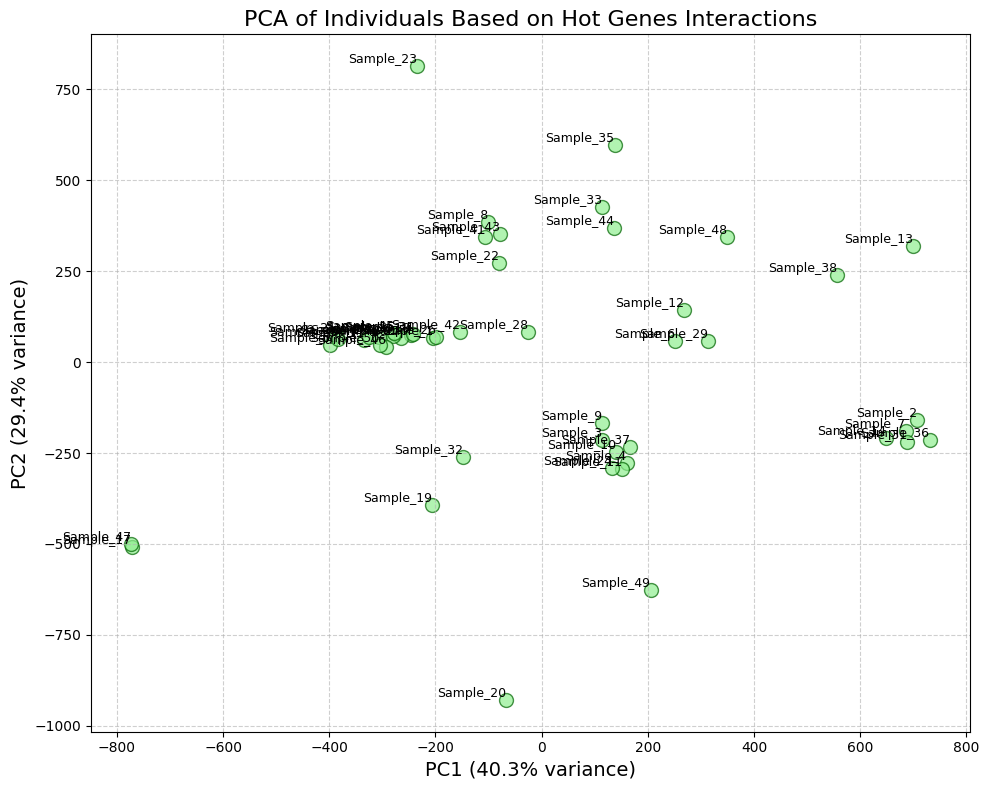

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract only the numerical values (Sample_1...Sample_50)
data_values = filtered_df.drop(columns=["tf", "gene", "Row_Variance"])

# Transpose the data so that individuals are rows
data_indiv = data_values.T
data_indiv.index.name = "Individual"

# Perform PCA (reducing to 2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_indiv)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, c="lightgreen", edgecolor="darkgreen", alpha=0.7)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("PCA of Individuals Based on Hot Genes Interactions", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)

# Customize grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

**Now do clustering**

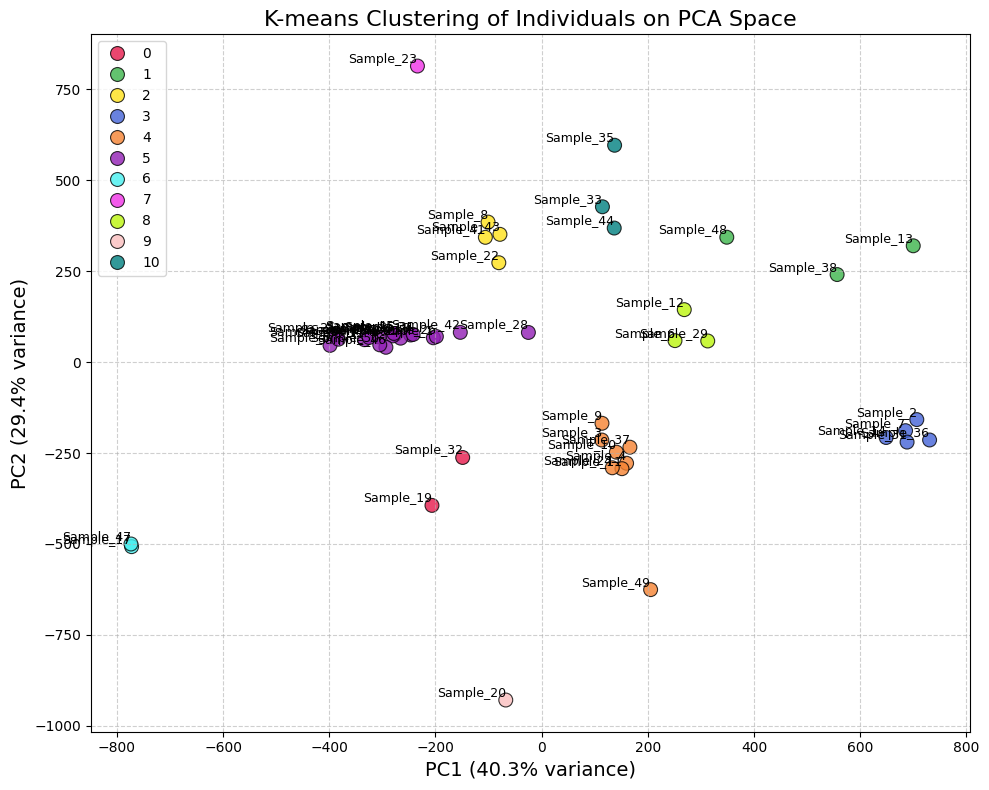

In [24]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Choose number of clusters (you can tune this!)
n_clusters = 11
kmeans_hot = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_hot = kmeans_hot.fit_predict(pca_result)

# Manually define a palette with at least 11 distinct colors
#palette = sns.color_palette("tab20", n_colors=n_clusters)
palette = [
    "#e6194b",  # rosso vivo
    "#3cb44b",  # verde acceso
    "#ffe119",  # giallo brillante
    "#4363d8",  # blu intenso
    "#f58231",  # arancione forte
    "#911eb4",  # viola vivace
    "#46f0f0",  # ciano brillante
    "#f032e6",  # rosa acceso
    "#bcf60c",  # lime elettrico
    "#fabebe",  # rosa chiaro
    "#008080"   # teal profondo
]

# Plot with cluster colors
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=cluster_labels_hot, palette=palette, s=100, edgecolor='black', alpha=0.8)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("K-means Clustering of Individuals on PCA Space", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


In [25]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pca_result, cluster_labels_hot)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.64


In [26]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("Calinski-Harabasz:", calinski_harabasz_score(pca_result, cluster_labels_hot))
print("Davies-Bouldin:", davies_bouldin_score(pca_result, cluster_labels_hot))  # più basso è meglio


Calinski-Harabasz: 104.30470679754501
Davies-Bouldin: 0.38329789516857404


**Select the best n**

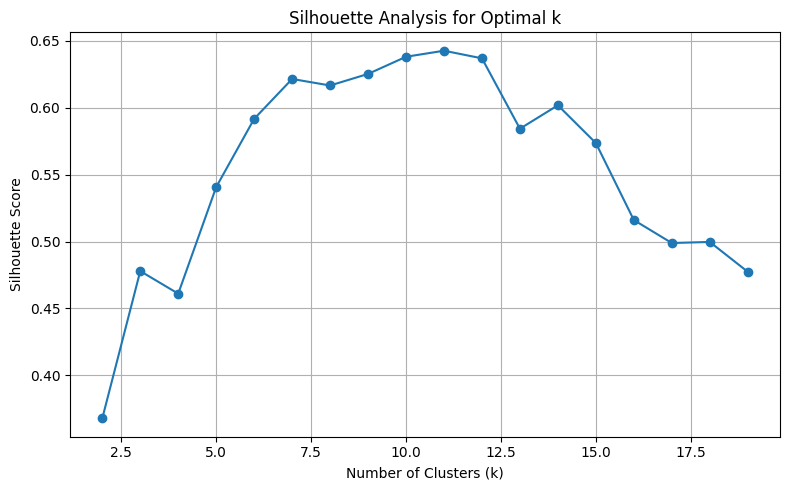

In [27]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()


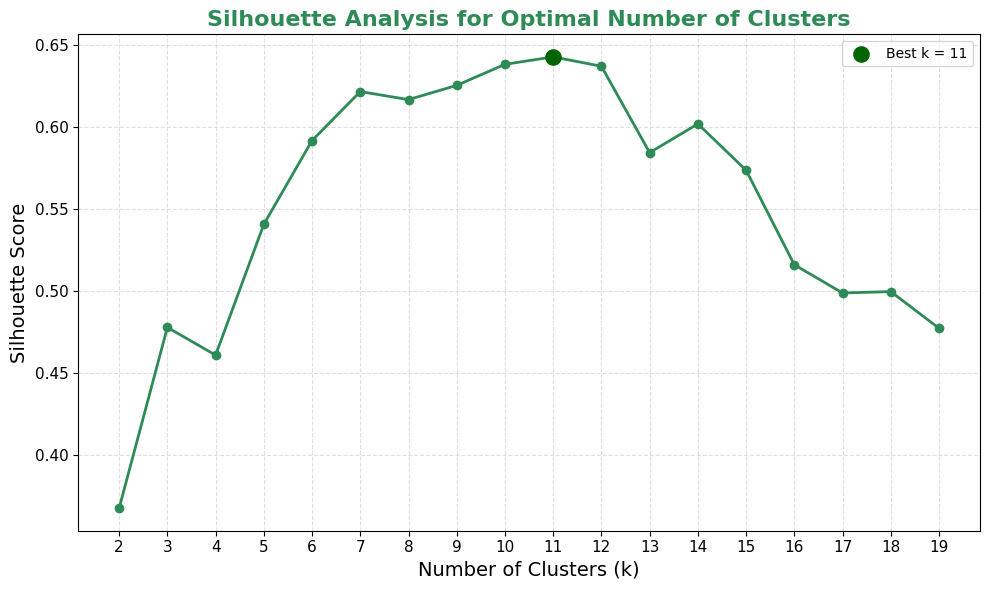

In [28]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calcolo dei silhouette score per diversi k
silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Trova k ottimale
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]

# Plot con toni verdi
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', color="#2e8b57", linewidth=2)
plt.scatter(best_k, max(silhouette_scores), color="#006400", s=120, zorder=5, label=f"Best k = {best_k}")

# Decorazioni
plt.title("Silhouette Analysis for Optimal Number of Clusters", fontsize=16, fontweight="bold", color="#2e8b57")
plt.xlabel("Number of Clusters (k)", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.xticks(K_range, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

# Show
plt.show()


## **Using all the genes**

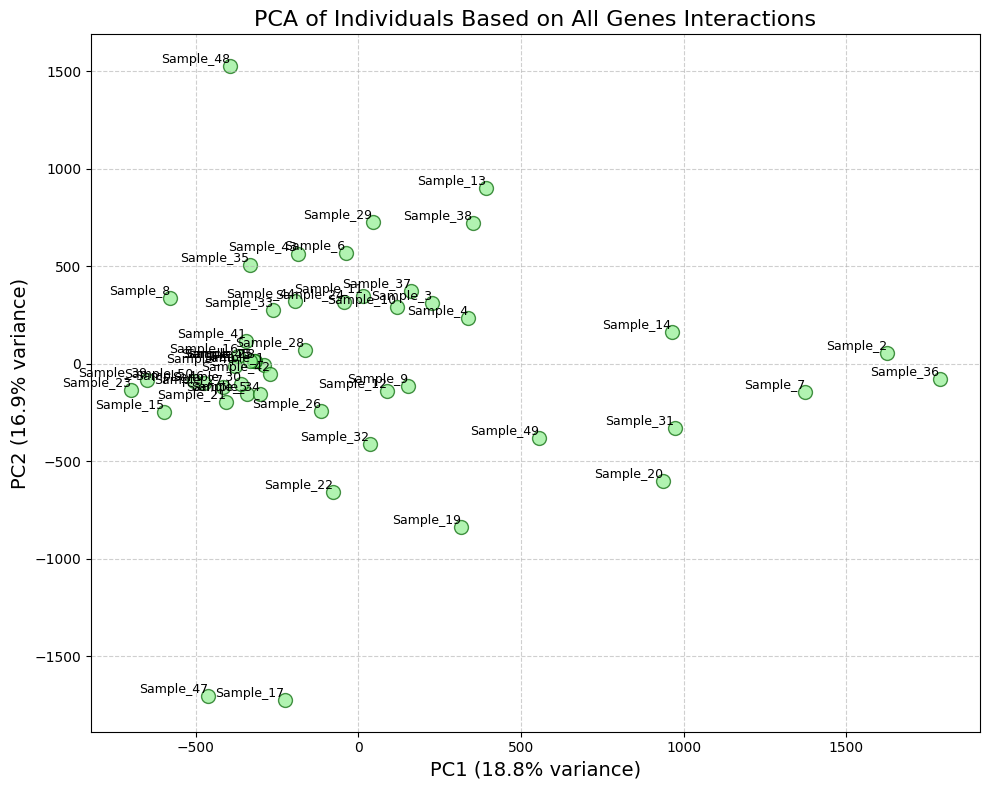

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract only the numerical values (Sample_1...Sample_50)
data_values = df.drop(columns=["tf", "gene", "Row_Variance"])

# Transpose the data so that individuals are rows
data_indiv = data_values.T
data_indiv.index.name = "Individual"

# Perform PCA (reducing to 2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_indiv)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, c="lightgreen", edgecolor="darkgreen", alpha=0.7)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("PCA of Individuals Based on All Genes Interactions", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)

# Customize grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()



**Now do clustering**

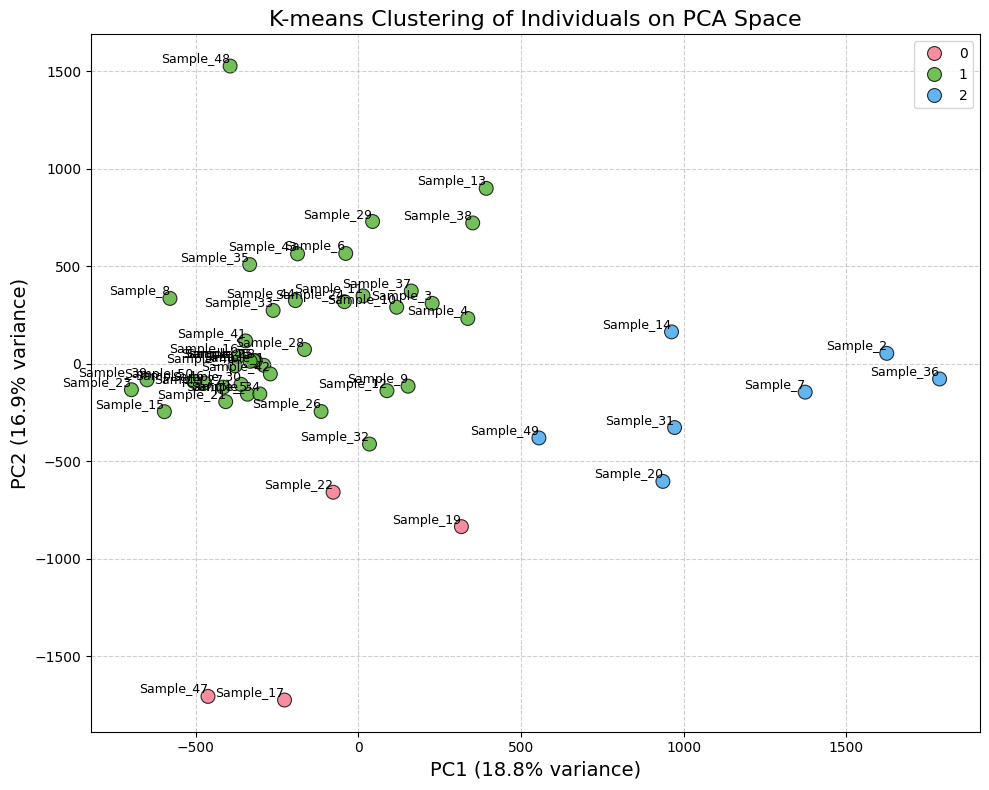

In [30]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Choose number of clusters (you can tune this!)
n_clusters = 3
kmeans_all = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_all = kmeans_all.fit_predict(pca_result)

# Manually define a palette with at least 11 distinct colors
palette = sns.color_palette("husl", n_colors=n_clusters)

# Plot with cluster colors
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=cluster_labels_all, palette=palette, s=100, edgecolor='black', alpha=0.8)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("K-means Clustering of Individuals on PCA Space", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


**Select the best n**

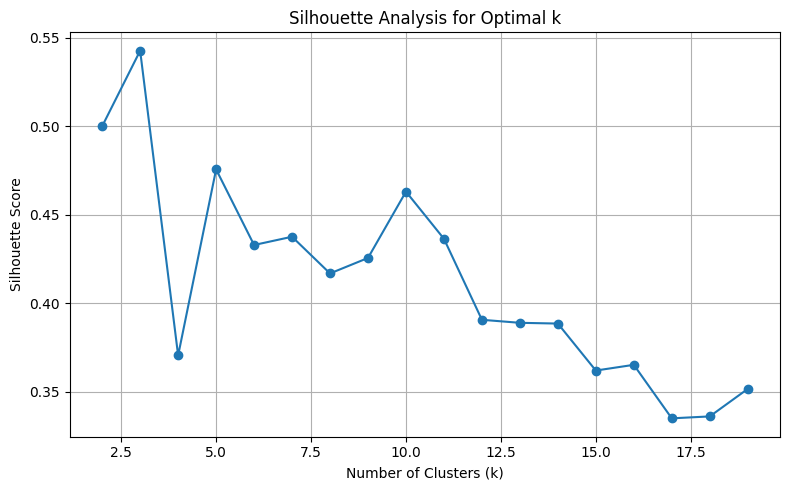

In [31]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()


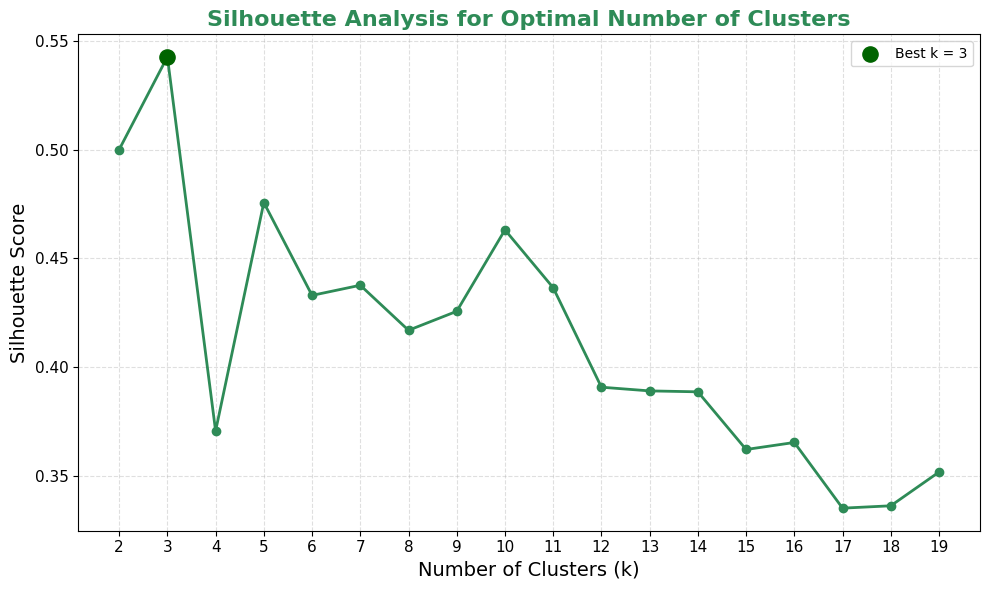

In [32]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calcolo dei silhouette score per diversi k
silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Trova k ottimale
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]

# Plot con toni verdi
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', color="#2e8b57", linewidth=2)
plt.scatter(best_k, max(silhouette_scores), color="#006400", s=120, zorder=5, label=f"Best k = {best_k}")

# Decorazioni
plt.title("Silhouette Analysis for Optimal Number of Clusters", fontsize=16, fontweight="bold", color="#2e8b57")
plt.xlabel("Number of Clusters (k)", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.xticks(K_range, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

# Show
plt.show()


## **Using genes in each community**

**2) GENES IN EACH COMMUNITY**

* Community 0

In [33]:
threshold_to_extract = 'Q98.0'
cluster_to_extract = 0


genes_98_0 = [
    gene for gene, cluster_id in gene_cluster_map[threshold_to_extract].items()
    if cluster_id == cluster_to_extract
]

print(f"Genes at the threshold {threshold_to_extract}, cluster {cluster_to_extract}:")
print(genes_98_0)

len(genes_98_0)

Genes at the threshold Q98.0, cluster 0:
['MAGED1', 'AIFM1', 'MAOB', 'TMSB15A', 'MAP3K15', 'SLC6A8', 'NDUFB11', 'ARHGAP6', 'GAGE12G', 'ZC3H12B', 'GAGE12D', 'RBM10', 'BEX5', 'RPS4Y1', 'ARSD', 'PDZD4', 'KIAA1210', 'RAI2', 'RAB41', 'CXorf38', 'TSPY1', 'PDZD11', 'NLGN4Y', 'FTHL17', 'KDM6A', 'ARHGEF9', 'UTY', 'NDUFA1', 'IRAK1', 'IGBP1', 'ZMAT1', 'PIGA', 'RBMY1D', 'CSAG1', 'DMD', 'NLGN4X', 'SH3KBP1', 'TMSB4X', 'PPEF1', 'MSL3', 'ZNF630', 'SASH3', 'GPM6B', 'TAF7L', 'ZFY', 'MID1IP1', 'SLC38A5', 'SLC25A14', 'ARHGAP4', 'ARHGEF6', 'KIF4A', 'HSD17B10', 'TFE3', 'NLGN3', 'PAK3', 'BTK', 'TSPAN6', 'KLHL34']


58

In [34]:
filtered_df_0 = df[df['tf'].isin(genes_98_0) & df['gene'].isin(genes_98_0)]
filtered_df_0

,tf,gene,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,...,Sample_42,Sample_43,Sample_44,Sample_45,Sample_46,Sample_47,Sample_48,Sample_49,Sample_50,Row_Variance
1797,AIFM1,ZFY,-4.705697,-7.091585,-5.028308,-4.655543,-4.891598,-3.994545,-7.018363,-3.426761,...,-4.665279,-3.363741,-3.622505,-4.767263,-4.984491,-7.160513,-5.008811,-4.973102,-4.933430,1.519480
1806,ARHGAP4,ZFY,-4.181078,-6.026539,-4.094441,-4.637203,-4.642935,-4.293888,-5.680378,-3.423280,...,-4.214483,-3.400350,-2.976249,-4.161656,-4.032919,-6.267261,-3.422411,-3.815633,-4.224208,1.022823
1807,ARHGAP6,ZFY,-4.435941,-6.960641,-4.886712,-4.342135,-4.563082,-3.777409,-6.679068,-5.299020,...,-4.647939,-2.304570,-4.104319,-4.790611,-4.500258,-6.005889,-7.276779,-3.734154,-4.442211,1.357834
1808,ARHGEF6,ZFY,3.890535,5.746403,4.067875,3.985235,4.183299,3.295945,5.557593,4.037896,...,3.980285,2.242753,3.328971,4.108574,4.080141,5.983196,6.676752,3.464398,4.040649,0.913473
1809,ARHGEF9,ZFY,3.997588,6.419115,4.049992,4.379486,4.621818,3.265529,5.627649,3.144769,...,3.979129,2.475605,3.443224,4.052657,4.073995,4.583976,6.208824,3.958060,4.101910,0.962046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128849,UTY,ARHGAP6,-4.115802,-5.882976,-4.100084,-3.224549,-6.071500,-4.421567,-5.650381,-4.184789,...,-3.653488,-4.768957,-3.810825,-4.500261,-5.686288,-6.568236,-5.089014,-2.827765,-5.769306,1.119575
128860,ZC3H12B,ARHGAP6,4.311069,6.589686,3.765689,3.096904,7.386324,5.261288,6.239342,4.542777,...,3.865920,5.590925,5.247215,4.140917,5.453210,6.275101,5.443087,3.072662,6.207288,1.670024
128865,ZFY,ARHGAP6,-3.746354,-6.265391,-4.260126,-3.082252,-5.187468,-3.895490,-6.171319,-4.277301,...,-3.420524,-3.152570,-4.346459,-3.624080,-4.717482,-6.286568,-4.154350,-2.430757,-5.166053,1.271601
128867,ZMAT1,ARHGAP6,4.363501,6.176552,3.856012,3.121838,6.543509,4.011301,5.906051,4.590956,...,3.586018,3.516376,4.891207,3.390575,4.833476,6.061339,3.680762,2.951852,5.619170,1.596674


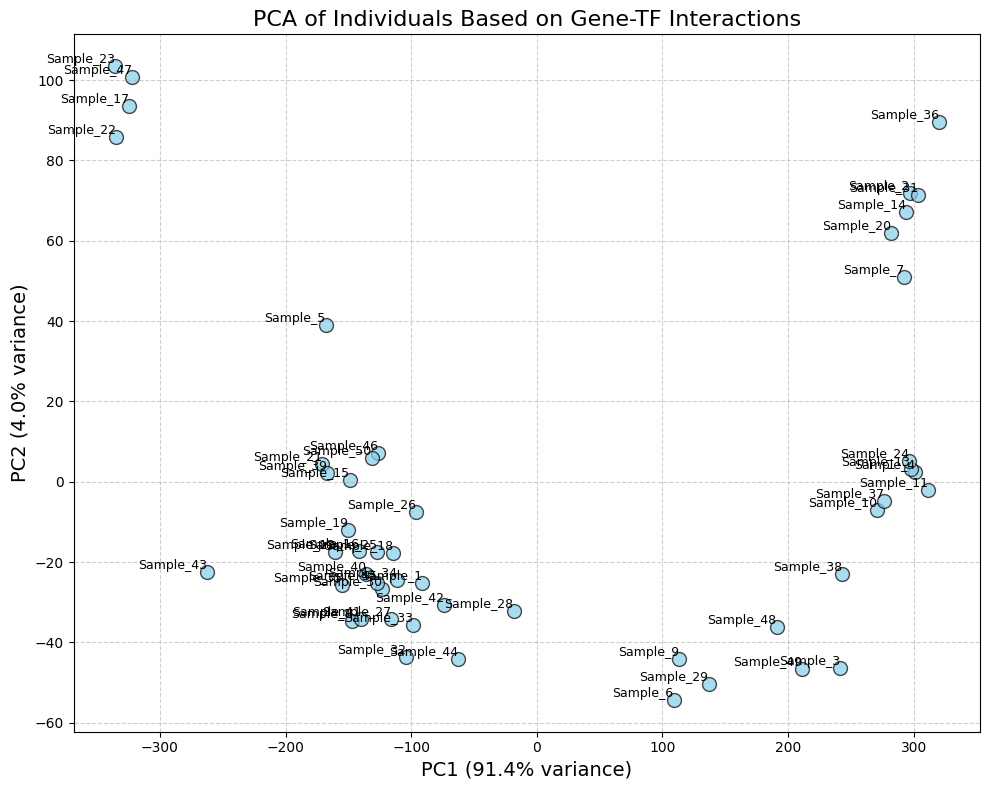

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract only the numerical values (Sample_1...Sample_50)
data_values = filtered_df_0.drop(columns=["tf", "gene", "Row_Variance"])

# Transpose the data so that individuals are rows
data_indiv = data_values.T
data_indiv.index.name = "Individual"

# Perform PCA (reducing to 2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_indiv)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, c="skyblue", edgecolor="black", alpha=0.7)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("PCA of Individuals Based on Gene-TF Interactions", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)

# Customize grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()



**Now do clustering**

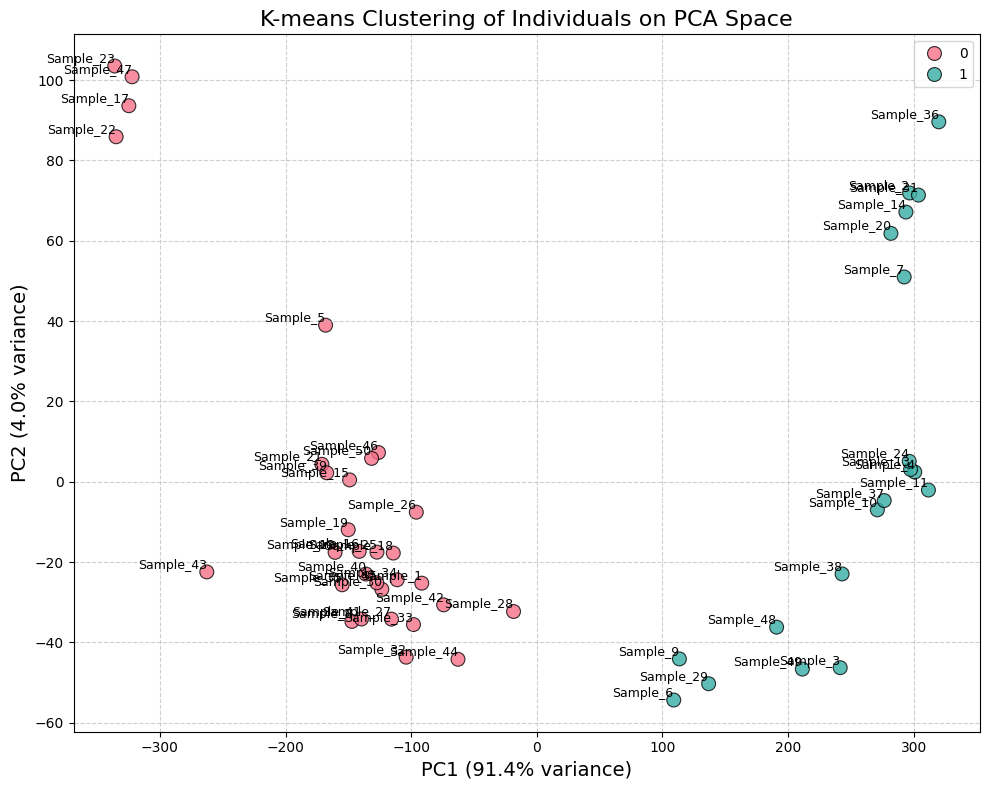

In [36]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Choose number of clusters (you can tune this!)
n_clusters = 2
kmeans_0 = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_0 = kmeans_0.fit_predict(pca_result)

# Manually define a palette with at least 11 distinct colors
palette = sns.color_palette("husl", n_colors=n_clusters)

# Plot with cluster colors
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=cluster_labels_0, palette=palette, s=100, edgecolor='black', alpha=0.8)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("K-means Clustering of Individuals on PCA Space", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


In [37]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pca_result, cluster_labels_0)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.76


In [38]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("Calinski-Harabasz:", calinski_harabasz_score(pca_result, cluster_labels_0))
print("Davies-Bouldin:", davies_bouldin_score(pca_result, cluster_labels_0))  # più basso è meglio


Calinski-Harabasz: 251.94470974469112
Davies-Bouldin: 0.3392164298247738


**Select the best n**

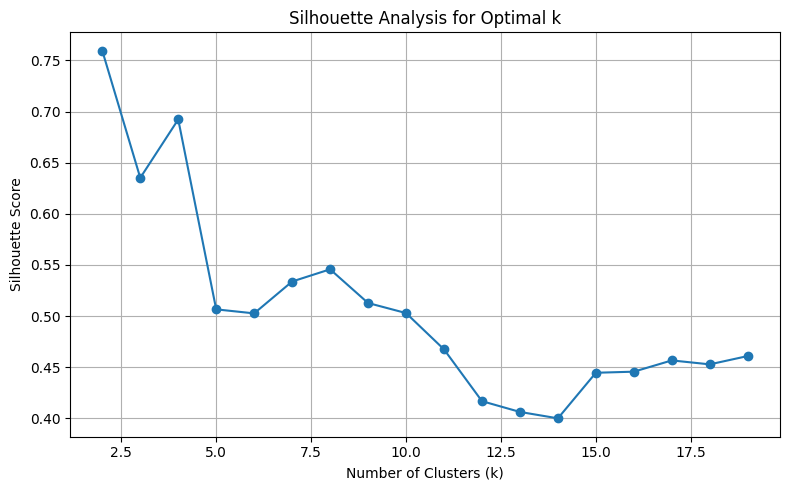

In [39]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()


* Community 1

In [40]:
threshold_to_extract = 'Q98.0'
cluster_to_extract = 1


genes_98_1 = [
    gene for gene, cluster_id in gene_cluster_map[threshold_to_extract].items()
    if cluster_id == cluster_to_extract
]

print(f"Genes at the threshold {threshold_to_extract}, cluster {cluster_to_extract}:")
print(genes_98_1)

len(genes_98_1)

Genes at the threshold Q98.0, cluster 1:
['APOOL', 'MAMLD1', 'TAF9B', 'CSTF2', 'GRIA3', 'PFKFB1', 'GABRQ', 'PCDH19', 'MBTPS2', 'MAGIX', 'CDK16', 'HS6ST2', 'DDX3X', 'UPRT', 'RAP2C', 'NUDT10', 'FAM9B', 'GAGE12B', 'ZRSR2', 'CNKSR2', 'PCDH11Y', 'GAGE12H', 'ZNF449', 'AP1S2', 'ZNF81', 'AMOT', 'PAGE2B', 'SLC25A43', 'BCORL1', 'FRMPD4', 'SCML1', 'SLC25A5', 'CLCN5', 'NHS', 'NAP1L3', 'ZXDA', 'ATRX', 'CITED1', 'UBQLN2', 'ARMCX2', 'RPL10', 'TBL1X', 'RIBC1', 'CHIC1', 'MORF4L2', 'VBP1', 'MBNL3', 'MAGEC3', 'BCOR', 'HMGB3']


50

In [41]:
filtered_df_1 = df[df['tf'].isin(genes_98_1) & df['gene'].isin(genes_98_1)]
filtered_df_1

,tf,gene,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,...,Sample_42,Sample_43,Sample_44,Sample_45,Sample_46,Sample_47,Sample_48,Sample_49,Sample_50,Row_Variance
1441,AMOT,PCDH11Y,5.032013,6.772230,6.317274,4.539820,4.422478,5.072354,6.774531,5.911761,...,5.393000,5.063623,4.847803,6.077821,5.719351,6.545418,5.629776,5.476925,4.687925,0.515249
1442,AP1S2,PCDH11Y,4.730979,6.281401,4.110611,3.458172,3.054165,5.220190,5.820357,5.459722,...,3.661475,5.699990,3.389536,4.330135,6.286497,6.623339,5.258354,6.059470,3.042480,1.415035
1445,APOOL,PCDH11Y,-0.500162,13.195315,-2.497965,-1.781141,-1.662874,3.184926,2.146683,4.316566,...,-1.252844,9.518030,0.605693,-5.009425,-4.979824,-15.633722,15.398379,-0.049821,-2.259487,39.259680
1452,ARMCX2,PCDH11Y,-3.967334,-6.343077,-4.079326,-2.971526,-2.686646,-4.546529,-5.586113,-5.132661,...,-3.782859,-5.265641,-3.329265,-4.280747,-5.250707,-5.187853,-5.389696,-4.737276,-3.172916,1.186843
1461,ATRX,PCDH11Y,-4.191132,-6.324780,-4.486452,-3.061294,-2.904560,-4.463131,-6.292342,-4.818481,...,-3.671541,-4.852146,-3.364611,-4.259851,-5.168672,-6.090501,-4.862765,-4.860232,-3.186801,1.182415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127415,VBP1,MBNL3,4.120957,5.351599,4.360725,4.087234,4.078129,3.889416,5.359765,4.151975,...,4.009267,3.902967,3.745384,4.113864,4.318958,2.538510,4.394387,4.179307,4.162254,0.418088
127437,ZNF449,MBNL3,-4.345295,-4.976721,-4.988080,-4.313793,-4.099789,-4.754633,-6.267872,-4.193145,...,-4.762428,-5.348794,-4.657143,-4.562540,-4.607889,-2.372738,-5.160660,-3.854398,-4.817854,0.754898
127441,ZNF81,MBNL3,-4.968699,-6.049466,-5.020058,-4.833293,-4.995535,-4.558188,-5.833316,-4.343056,...,-4.455833,-4.420600,-5.307311,-4.465334,-4.356490,-2.698826,-4.917975,-4.798562,-4.389870,0.478150
127442,ZRSR2,MBNL3,-4.964417,-6.310915,-5.367527,-4.590836,-4.267015,-3.770551,-6.263324,-4.647762,...,-4.747347,-4.085808,-4.341780,-4.895970,-4.490308,-2.561364,-4.202699,-4.447100,-4.247369,0.827414


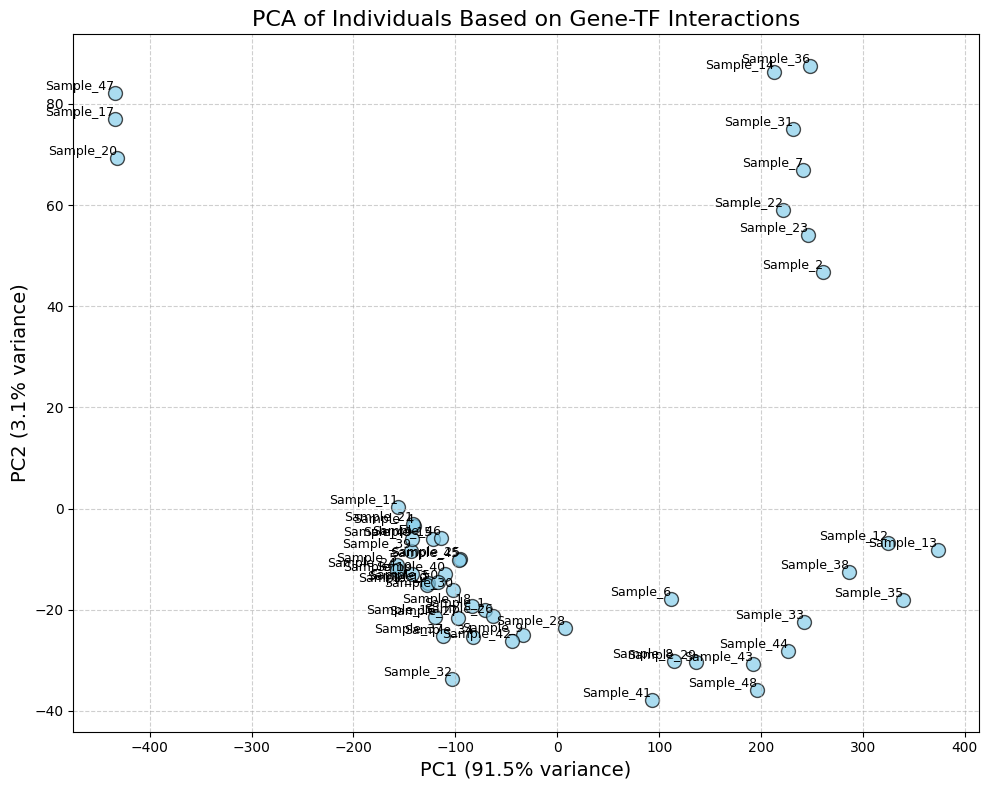

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract only the numerical values (Sample_1...Sample_50)
data_values = filtered_df_1.drop(columns=["tf", "gene", "Row_Variance"])

# Transpose the data so that individuals are rows
data_indiv = data_values.T
data_indiv.index.name = "Individual"

# Perform PCA (reducing to 2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_indiv)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, c="skyblue", edgecolor="black", alpha=0.7)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("PCA of Individuals Based on Gene-TF Interactions", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)

# Customize grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()



**Now do clustering**

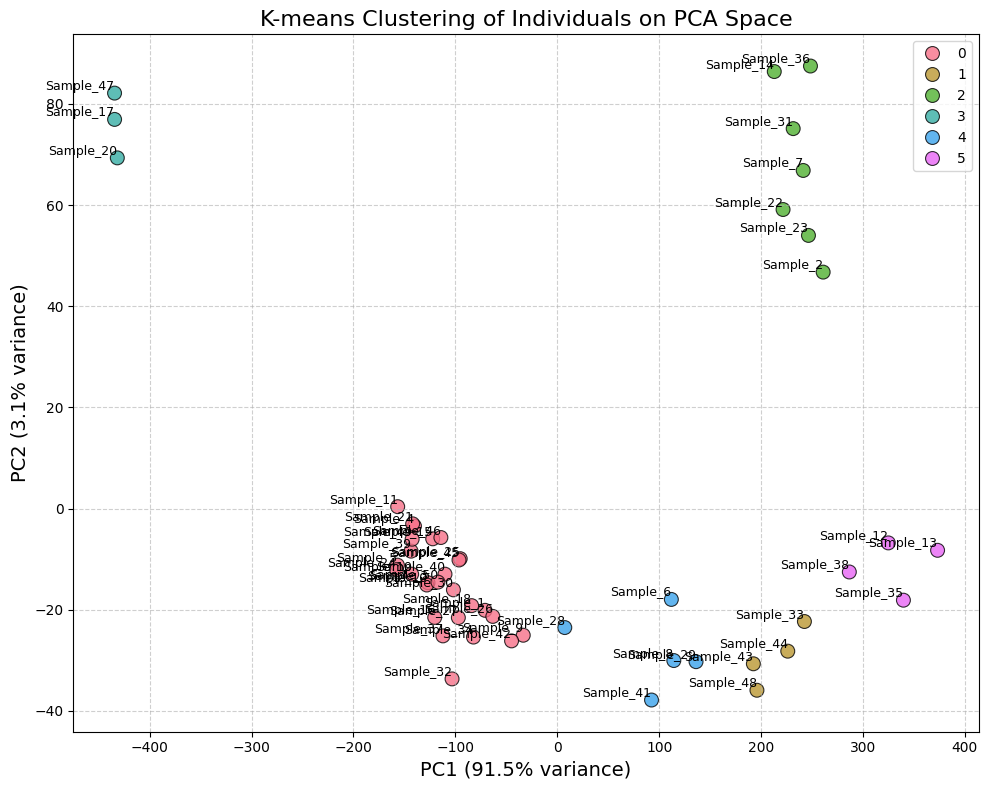

In [43]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Choose number of clusters (you can tune this!)
n_clusters = 6
kmeans_1 = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_1 = kmeans_1.fit_predict(pca_result)

# Manually define a palette with at least 11 distinct colors
palette = sns.color_palette("husl", n_colors=n_clusters)

# Plot with cluster colors
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=cluster_labels_1, palette=palette, s=100, edgecolor='black', alpha=0.8)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("K-means Clustering of Individuals on PCA Space", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pca_result, cluster_labels_1)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.73


In [45]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("Calinski-Harabasz:", calinski_harabasz_score(pca_result, cluster_labels_1))
print("Davies-Bouldin:", davies_bouldin_score(pca_result, cluster_labels_1))  # più basso è meglio


Calinski-Harabasz: 357.4675622644241
Davies-Bouldin: 0.3577149015146817


**Select the best n**

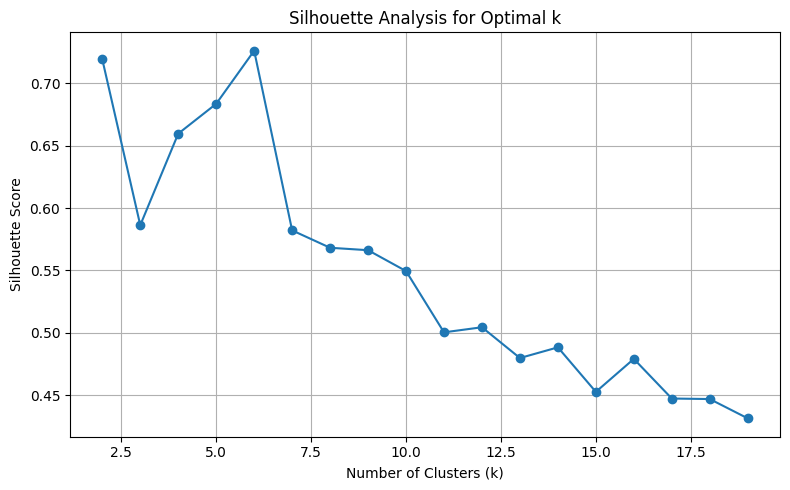

In [46]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()


* Community 2

In [47]:
threshold_to_extract = 'Q98.0'
cluster_to_extract = 2


genes_98_2 = [
    gene for gene, cluster_id in gene_cluster_map[threshold_to_extract].items()
    if cluster_id == cluster_to_extract
]

print(f"Genes at the threshold {threshold_to_extract}, cluster {cluster_to_extract}:")
print(genes_98_2)

len(genes_98_2)

Genes at the threshold Q98.0, cluster 2:
['LONRF3', 'AFF2', 'FGF16', 'NDP', 'RPS4X', 'PIM2', 'DUSP9', 'OTUD5', 'BEND2', 'HCFC1', 'FAM47C', 'IL1RAPL1', 'TMEM187', 'PJA1', 'FAM3A', 'DYNLT3', 'STARD8', 'SH3BGRL', 'PRRG3', 'PGK1', 'UBL4A', 'ARMCX1', 'DDX3Y', 'NAA10', 'SHROOM2', 'RPGR', 'FGF13']


27

In [48]:
filtered_df_2 = df[df['tf'].isin(genes_98_2) & df['gene'].isin(genes_98_2)]
filtered_df_2

,tf,gene,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,...,Sample_42,Sample_43,Sample_44,Sample_45,Sample_46,Sample_47,Sample_48,Sample_49,Sample_50,Row_Variance
4309,AFF2,DDX3Y,-3.497957,0.301565,-6.035389,0.838791,-2.972838,-0.151382,4.026279,-6.390880,...,-7.970091,-5.066368,-1.834662,-10.158025,0.431540,11.003194,-14.613444,12.501355,-0.783704,39.076381
4323,ARMCX1,DDX3Y,4.741937,7.232665,6.828576,5.450266,5.270240,5.724410,7.451952,5.273979,...,5.775866,6.474774,4.582278,5.975680,4.995212,6.546160,6.547773,5.855557,4.896327,0.812706
4337,BEND2,DDX3Y,5.270205,7.134901,5.605310,6.270279,6.567918,4.748373,7.384638,6.028813,...,5.321927,4.407858,4.679039,5.482093,4.641431,7.359364,5.554317,6.425682,4.405850,1.145046
4369,DDX3Y,DDX3Y,5.194754,6.678103,6.320446,6.321029,6.240734,5.745509,7.061399,5.722846,...,5.969077,6.915045,5.174004,6.503219,4.963753,6.297448,6.687734,5.479178,4.847242,0.561702
4375,DUSP9,DDX3Y,5.052176,7.620020,5.501560,6.402841,6.601702,5.609734,7.082215,6.608869,...,5.078923,5.853986,3.915407,5.367270,4.553061,6.606850,6.276072,6.286277,4.217149,1.094039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126990,SH3BGRL,FAM47C,5.920459,7.142917,6.291602,5.623383,5.249932,5.615353,7.601277,4.797143,...,6.091825,6.150648,4.563164,6.308244,4.316938,6.404601,6.055075,5.531936,5.412381,0.861095
126992,SHROOM2,FAM47C,5.668608,7.110494,6.071915,4.909860,5.406495,5.271699,6.986549,3.889065,...,5.859087,6.374446,5.492036,5.908430,4.826635,6.158062,6.822101,4.777745,4.937105,0.807463
127010,STARD8,FAM47C,6.276469,7.464212,6.804435,5.583409,5.287929,5.469845,7.542888,4.123251,...,6.549233,7.039585,4.566117,7.180638,4.711596,6.461648,6.950386,4.722285,5.274657,1.178229
127031,TMEM187,FAM47C,4.826091,7.117797,5.742372,5.385257,6.365418,5.370285,6.446582,4.284435,...,5.430231,5.691813,5.231144,5.708966,4.220586,6.393104,6.223638,5.144138,6.034710,0.837375


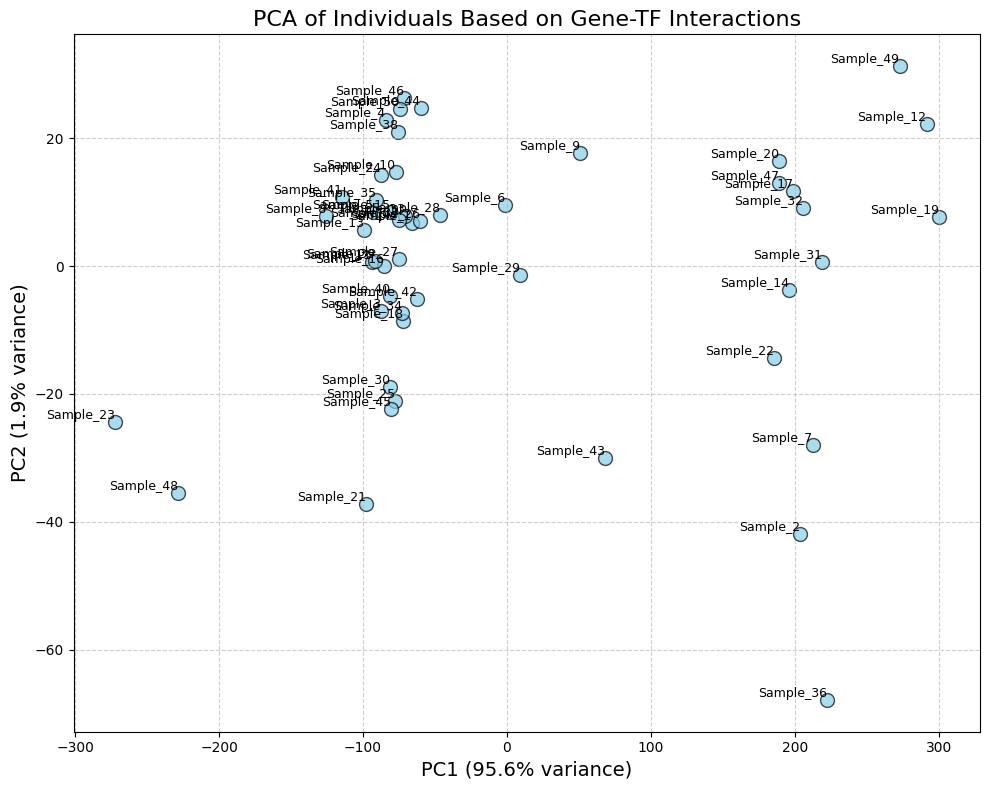

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract only the numerical values (Sample_1...Sample_50)
data_values = filtered_df_2.drop(columns=["tf", "gene", "Row_Variance"])

# Transpose the data so that individuals are rows
data_indiv = data_values.T
data_indiv.index.name = "Individual"

# Perform PCA (reducing to 2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_indiv)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, c="skyblue", edgecolor="black", alpha=0.7)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("PCA of Individuals Based on Gene-TF Interactions", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)

# Customize grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()



**Now do clustering**

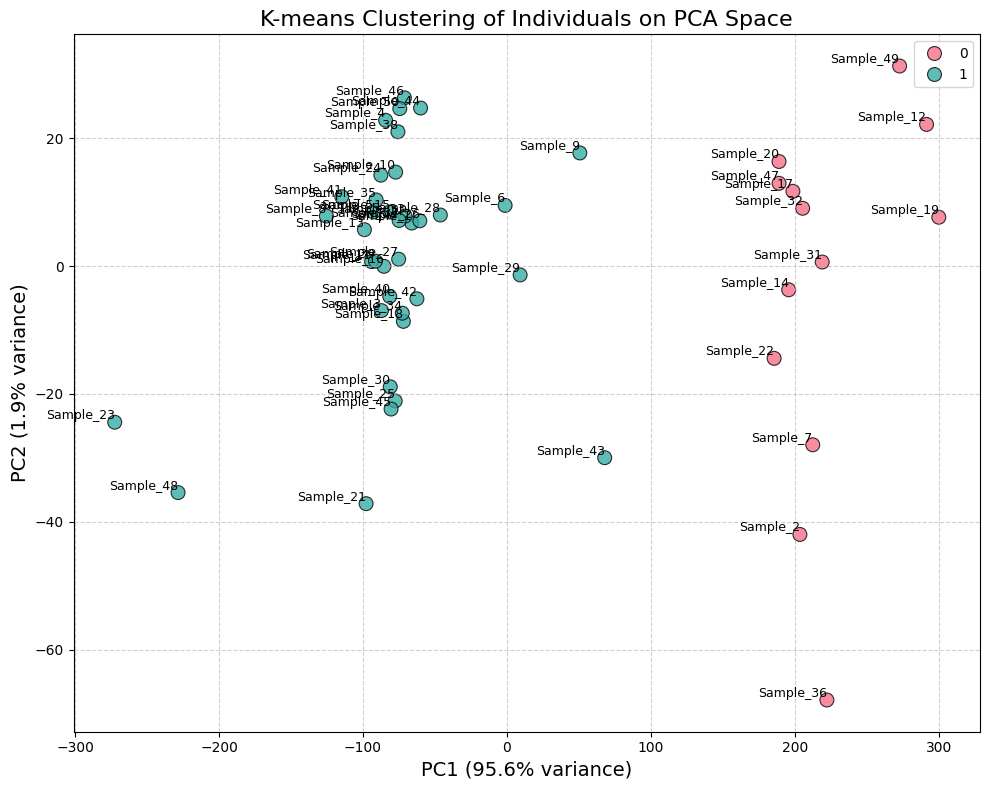

In [50]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Choose number of clusters (you can tune this!)
n_clusters = 2
kmeans_2 = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_2 = kmeans_2.fit_predict(pca_result)

# Manually define a palette with at least 11 distinct colors
palette = sns.color_palette("husl", n_colors=n_clusters)

# Plot with cluster colors
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=cluster_labels_2, palette=palette, s=100, edgecolor='black', alpha=0.8)

# Add labels to points
for i, sample in enumerate(data_indiv.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9, ha='right', va='bottom')

# Title and labels
plt.title("K-means Clustering of Individuals on PCA Space", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


In [51]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pca_result, cluster_labels_2)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.79


In [52]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("Calinski-Harabasz:", calinski_harabasz_score(pca_result, cluster_labels_2))
print("Davies-Bouldin:", davies_bouldin_score(pca_result, cluster_labels_2))  # più basso è meglio


Calinski-Harabasz: 263.0291344739084
Davies-Bouldin: 0.2630870148168709


**Select the best n**

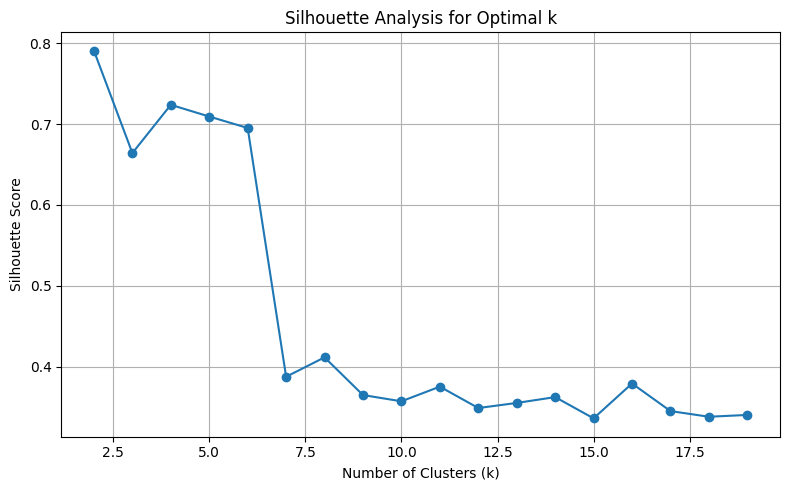

In [53]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()


# **3) Sankey to compare PCA+Kmeans results**

In [55]:
import pandas as pd
import plotly.graph_objects as go

# Lista di colori brillanti e distinti (fino a 21)
distinct_colors = [
    "rgb(230, 25, 75)", "rgb(60, 180, 75)", "rgb(255, 225, 25)", "rgb(0, 130, 200)", "rgb(245, 130, 48)",
    "rgb(145, 30, 180)", "rgb(70, 240, 240)", "rgb(240, 50, 230)", "rgb(210, 245, 60)", "rgb(250, 190, 190)",
    "rgb(0, 128, 128)", "rgb(230, 190, 255)", "rgb(170, 110, 40)", "rgb(255, 250, 200)", "rgb(128, 0, 0)",
    "rgb(170, 255, 195)", "rgb(0, 0, 128)", "rgb(128, 128, 0)", "rgb(255, 215, 180)", "rgb(128, 64, 0)",
    "rgb(255, 100, 255)"
]

# Create DataFrame from cluster label arrays
df_clusters = pd.DataFrame({
    'All Genes': cluster_labels_all,
    'Hot Genes': cluster_labels_hot,
    'Community 0': cluster_labels_0,
    'Community 1': cluster_labels_1,
    'Community 2': cluster_labels_2
})

# Build labels
label_list = []
label_color = {}
color_index = 0
for col in df_clusters.columns:
    clusters = df_clusters[col].unique()
    for c in clusters:
        label = f"{col}: Cluster {c}"
        label_list.append(label)
        label_color[label] = distinct_colors[color_index % len(distinct_colors)]
        color_index += 1
label_list = list(dict.fromkeys(label_list))  # Remove duplicates

# Map labels to indices
label_to_index = {label: i for i, label in enumerate(label_list)}

# Build source, target, value, link colors
source = []
target = []
value = []
link_colors = []

for i in range(len(df_clusters.columns) - 1):
    col1 = df_clusters.columns[i]
    col2 = df_clusters.columns[i + 1]
    grouped = df_clusters.groupby([col1, col2]).size().reset_index(name='count')
    for _, row in grouped.iterrows():
        src_label = f"{col1}: Cluster {row[col1]}"
        tgt_label = f"{col2}: Cluster {row[col2]}"
        source.append(label_to_index[src_label])
        target.append(label_to_index[tgt_label])
        value.append(row['count'])

        # Create rgba color with transparency from the source node color
        base_rgb = label_color[src_label]
        rgba_color = base_rgb.replace("rgb", "rgba").replace(")", ", 0.4)")
        link_colors.append(rgba_color)

# Sankey diagram
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=15,
        thickness=25,
        line=dict(color="gray", width=0.5),
        label=label_list,
        color=[label_color[label] for label in label_list],
        hovertemplate='Cluster: %{label}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='From %{source.label} to %{target.label}<br>Count: %{value}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="Sankey Diagram: Comparison of Clustering Assignments Across Gene Groups",
    font=dict(size=12, color='black'),
    height=700,
    width=1100,
    margin=dict(l=10, r=10, t=40, b=10),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title_x=0.5
)

fig.show()


# **5) Heatmaps to Compare**

In [92]:
import pandas as pd
import numpy as np

# Colonne con i dati dei sample
sample_cols = [col for col in filtered_df.columns if col.startswith('Sample_')]
X_hot = filtered_df[sample_cols].values

# Trasponi: individui come righe
X_hot_T = X_hot.T


In [93]:
import pandas as pd
import numpy as np

# Colonne con i dati dei sample
sample_cols = [col for col in df.columns if col.startswith('Sample_')]
X_all = df[sample_cols].values

# Trasponi: individui come righe
X_all_T = X_all.T


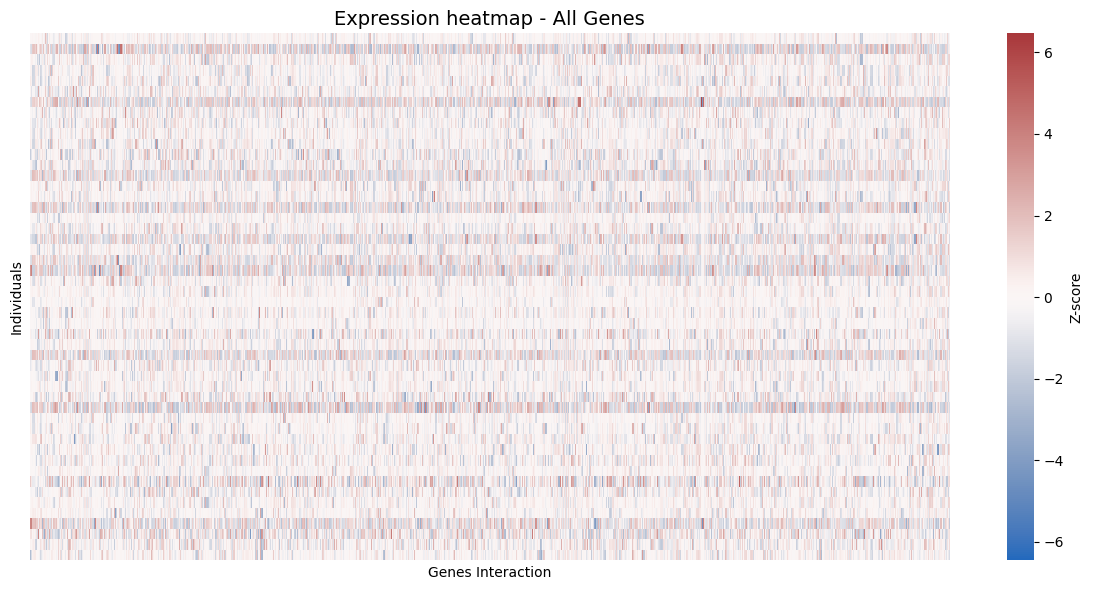

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Normalizza
scaler = StandardScaler()
hot_scaled = scaler.fit_transform(X_all_T)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.heatmap(hot_scaled, cmap='vlag', cbar_kws={'label': 'Z-score'})

# Rimuovi tick labels
ax.set_xticks([])
ax.set_yticks([])

# Aggiungi solo nomi degli assi
ax.set_xlabel('Genes Interaction')
ax.set_ylabel('Individuals')
ax.set_title('Expression heatmap - All Genes', fontsize=14)

plt.tight_layout()
plt.show()


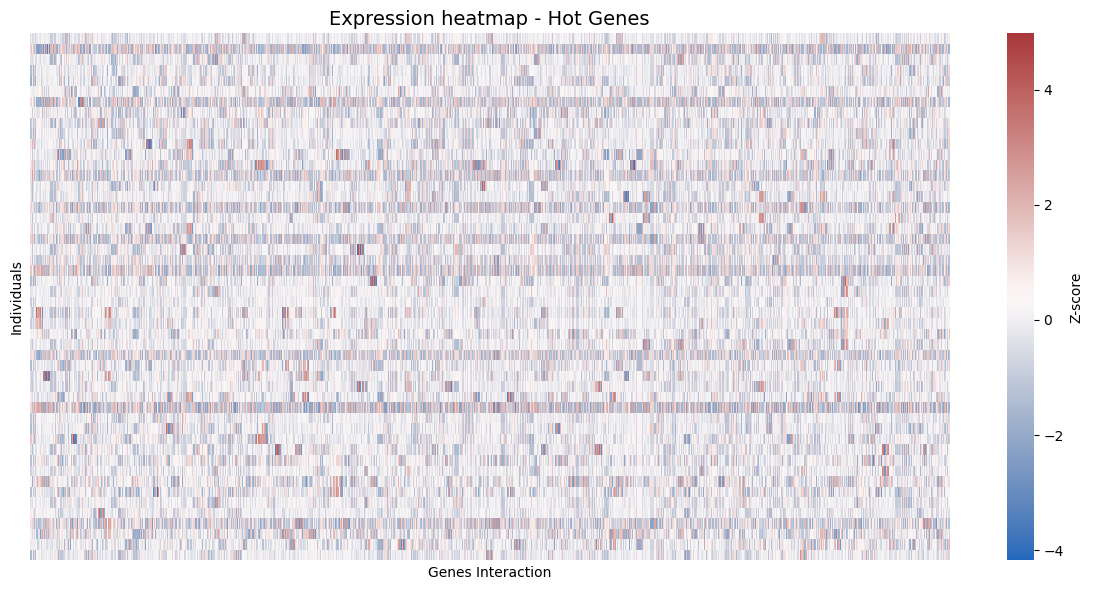

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Normalizza
scaler = StandardScaler()
hot_scaled = scaler.fit_transform(X_hot_T)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.heatmap(hot_scaled, cmap='vlag', cbar_kws={'label': 'Z-score'})

# Rimuovi tick labels
ax.set_xticks([])
ax.set_yticks([])

# Aggiungi solo nomi degli assi
ax.set_xlabel('Genes Interaction')
ax.set_ylabel('Individuals')
ax.set_title('Expression heatmap - Hot Genes', fontsize=14)

plt.tight_layout()
plt.show()


In [96]:
# Per Community 0
sample_cols = [col for col in filtered_df_0.columns if col.startswith('Sample_')]
X_0 = filtered_df_0[sample_cols]
X_0_T = X_0.T  # Trasponi
X_0_T.index.name = 'Sample'

# Per Community 1
sample_cols = [col for col in filtered_df_1.columns if col.startswith('Sample_')]
X_1 = filtered_df_1[sample_cols]
X_1_T = X_1.T
X_1_T.index.name = 'Sample'

# Per Community 2
sample_cols = [col for col in filtered_df_2.columns if col.startswith('Sample_')]
X_2 = filtered_df_2[sample_cols]
X_2_T = X_2.T
X_2_T.index.name = 'Sample'


# **6) T-sne**

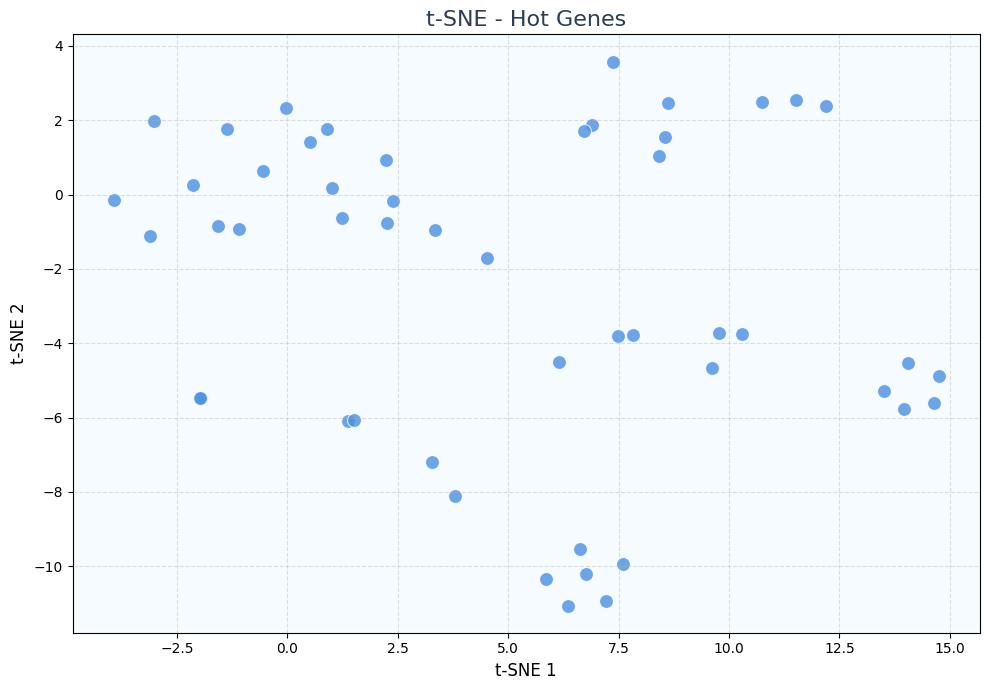

In [97]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Esegui t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results = tsne.fit_transform(X_hot_T)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    s=100,
    color="#4A90E2",  # azzurro brillante
    edgecolor="white",
    alpha=0.8
)

plt.title("t-SNE - Hot Genes", fontsize=16, color="#2C3E50")
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#F5FBFF')  # sfondo azzurrino chiaro
plt.tight_layout()
plt.show()


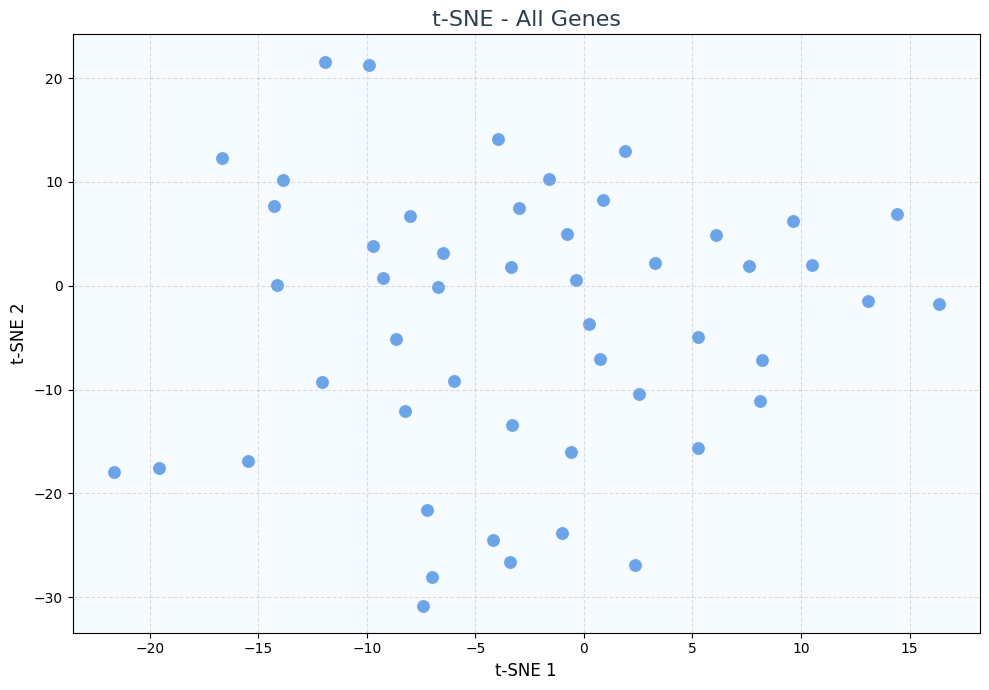

In [98]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Esegui t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results = tsne.fit_transform(X_all_T)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    s=100,
    color="#4A90E2",  # azzurro brillante
    edgecolor="white",
    alpha=0.8
)

plt.title("t-SNE - All Genes", fontsize=16, color="#2C3E50")
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#F5FBFF')  # sfondo azzurrino chiaro
plt.tight_layout()
plt.show()



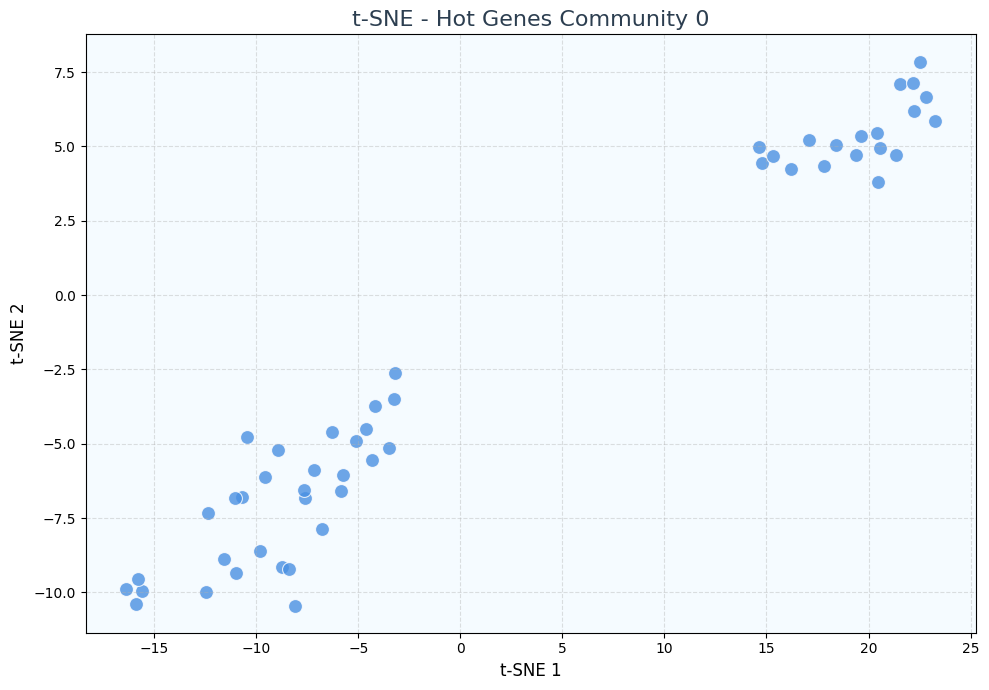

In [99]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Esegui t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results = tsne.fit_transform(X_0_T)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    s=100,
    color="#4A90E2",  # azzurro brillante
    edgecolor="white",
    alpha=0.8
)

plt.title("t-SNE - Hot Genes Community 0", fontsize=16, color="#2C3E50")
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#F5FBFF')  # sfondo azzurrino chiaro
plt.tight_layout()
plt.show()



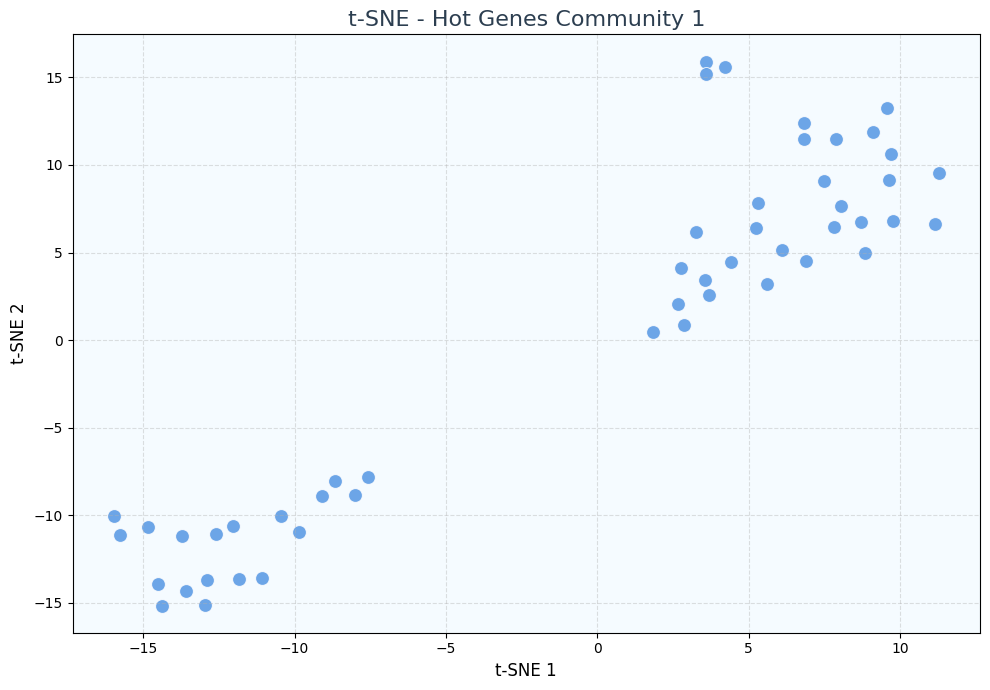

In [100]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Esegui t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results = tsne.fit_transform(X_1_T)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    s=100,
    color="#4A90E2",  # azzurro brillante
    edgecolor="white",
    alpha=0.8
)

plt.title("t-SNE - Hot Genes Community 1", fontsize=16, color="#2C3E50")
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#F5FBFF')  # sfondo azzurrino chiaro
plt.tight_layout()
plt.show()



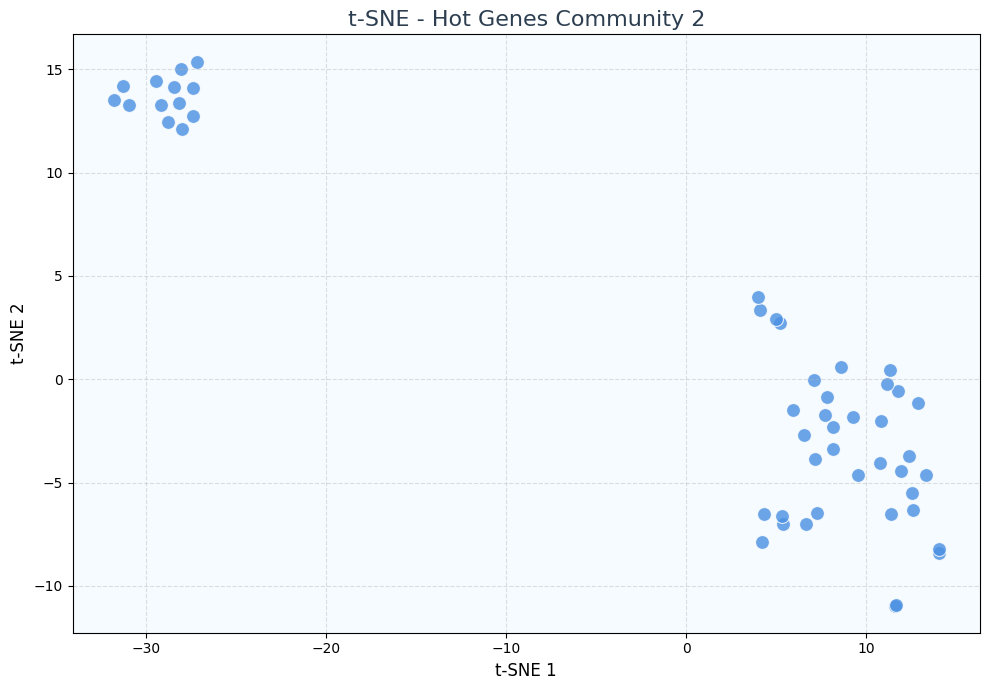

In [101]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Esegui t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results = tsne.fit_transform(X_2_T)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    s=100,
    color="#4A90E2",  # azzurro brillante
    edgecolor="white",
    alpha=0.8
)

plt.title("t-SNE - Hot Genes Community 2", fontsize=16, color="#2C3E50")
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#F5FBFF')  # sfondo azzurrino chiaro
plt.tight_layout()
plt.show()



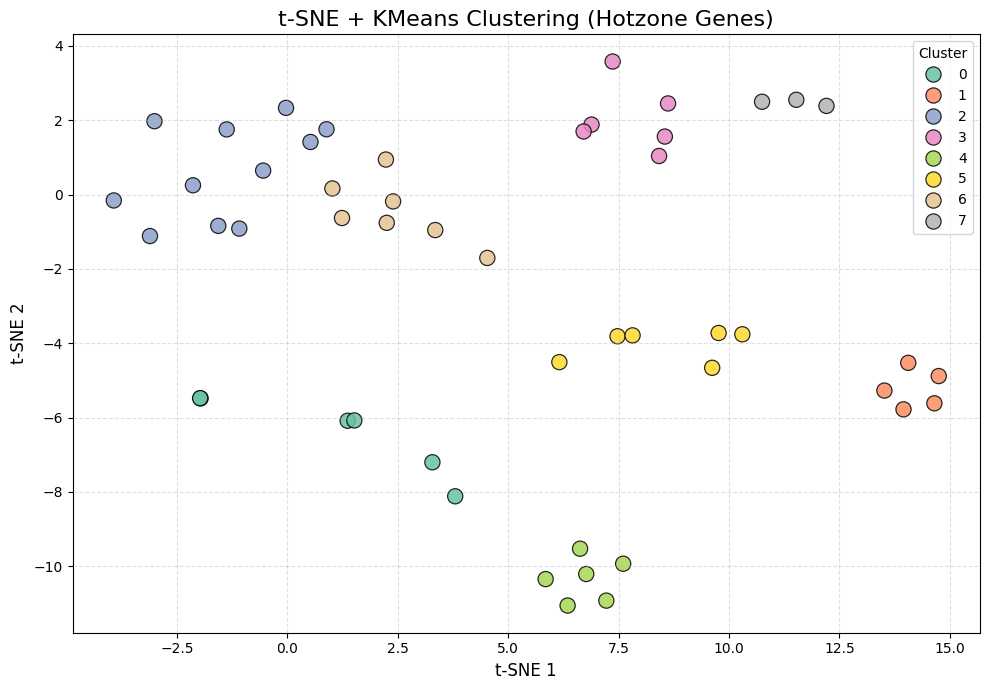

In [102]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE
tsne_hot = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results_hot = tsne_hot.fit_transform(X_hot_T)

# KMeans
kmeans_hot = KMeans(n_clusters=8, random_state=42)
cluster_labels_hot = kmeans_hot.fit_predict(tsne_results_hot)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results_hot[:, 0],
    y=tsne_results_hot[:, 1],
    hue=cluster_labels_hot,
    palette="Set2",
    s=120,              # Aumenta dimensione pallini
    edgecolor="black",  # Optional: bordo per maggiore contrasto
    alpha=0.85
)

plt.title("t-SNE + KMeans Clustering (Hotzone Genes)", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


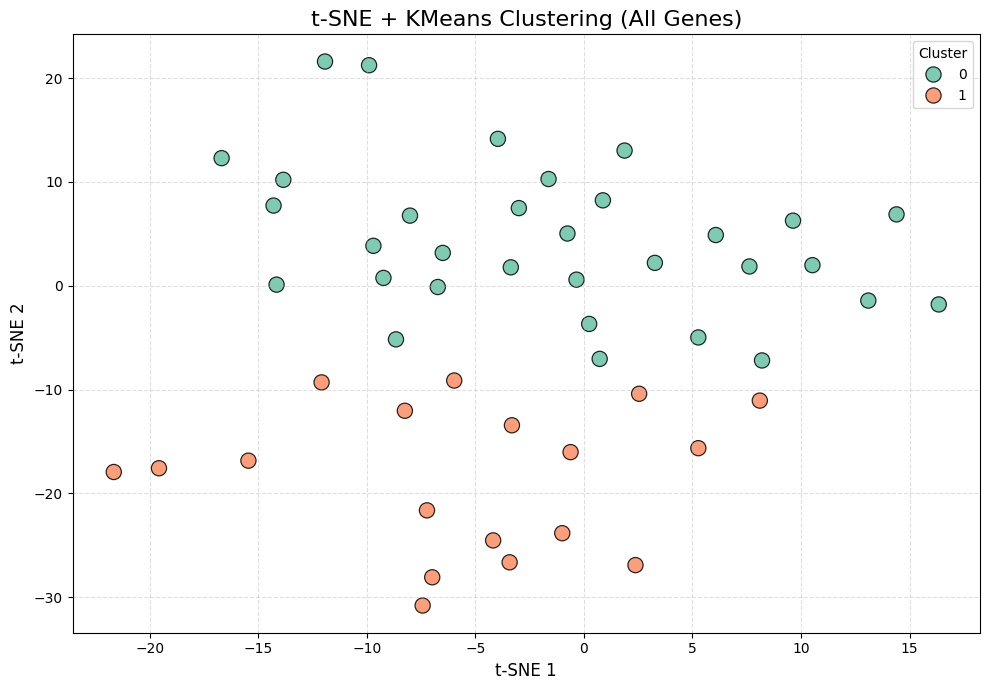

In [103]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE
tsne_all = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results_all = tsne_all.fit_transform(X_all_T)

# KMeans
kmeans_all = KMeans(n_clusters=2, random_state=42)
cluster_labels_all = kmeans_all.fit_predict(tsne_results_all)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results_all[:, 0],
    y=tsne_results_all[:, 1],
    hue=cluster_labels_all,
    palette="Set2",
    s=120,              # Aumenta dimensione pallini
    edgecolor="black",  # Optional: bordo per maggiore contrasto
    alpha=0.85
)

plt.title("t-SNE + KMeans Clustering (All Genes)", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



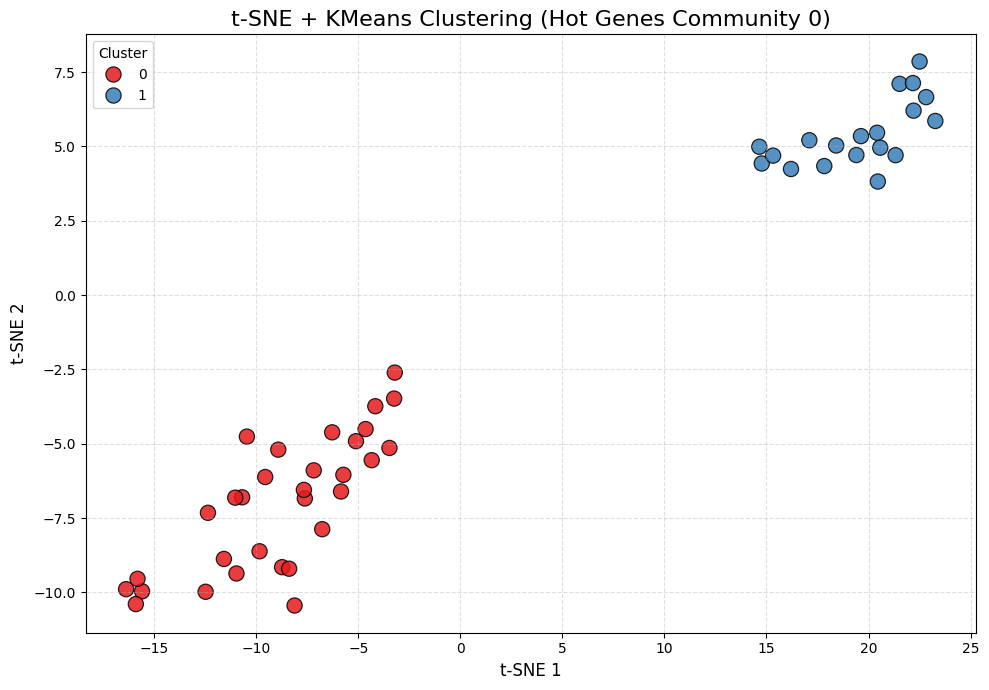

In [104]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE
tsne_0 = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results_0 = tsne_0.fit_transform(X_0_T)

# KMeans
kmeans_0 = KMeans(n_clusters=2, random_state=42)
cluster_labels_0 = kmeans_all.fit_predict(tsne_results_0)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results_0[:, 0],
    y=tsne_results_0[:, 1],
    hue=cluster_labels_0,
    palette="Set1",
    s=120,              # Aumenta dimensione pallini
    edgecolor="black",  # Optional: bordo per maggiore contrasto
    alpha=0.85
)

plt.title("t-SNE + KMeans Clustering (Hot Genes Community 0)", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



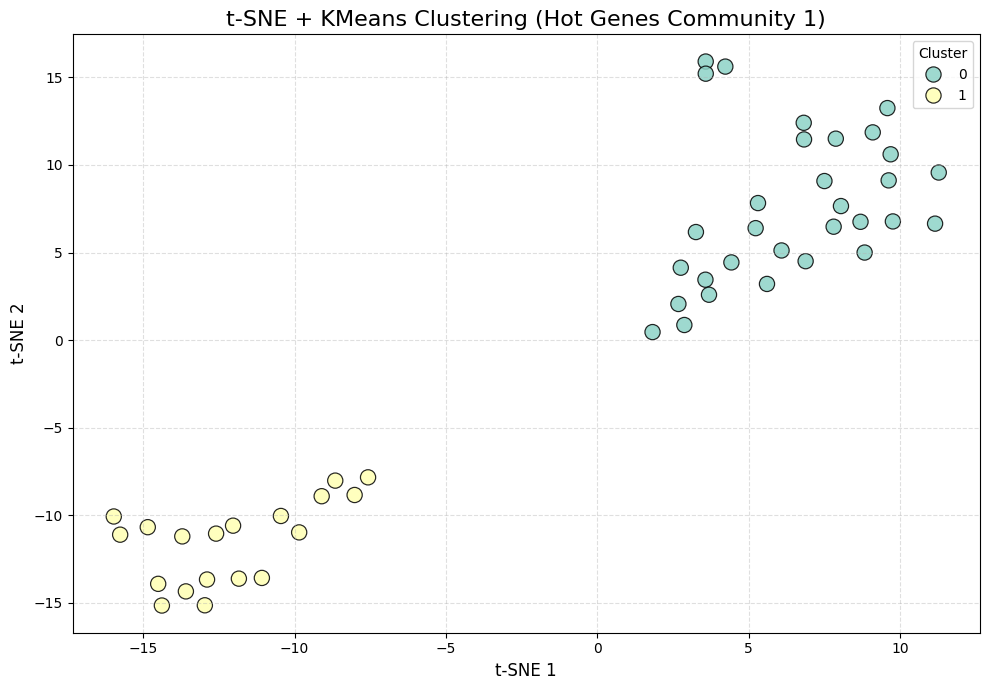

In [105]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE
tsne_1 = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results_1 = tsne_1.fit_transform(X_1_T)

# KMeans
kmeans_1 = KMeans(n_clusters=2, random_state=42)
cluster_labels_1 = kmeans_all.fit_predict(tsne_results_1)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results_1[:, 0],
    y=tsne_results_1[:, 1],
    hue=cluster_labels_1,
    palette="Set3",
    s=120,              # Aumenta dimensione pallini
    edgecolor="black",  # Optional: bordo per maggiore contrasto
    alpha=0.85
)

plt.title("t-SNE + KMeans Clustering (Hot Genes Community 1)", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



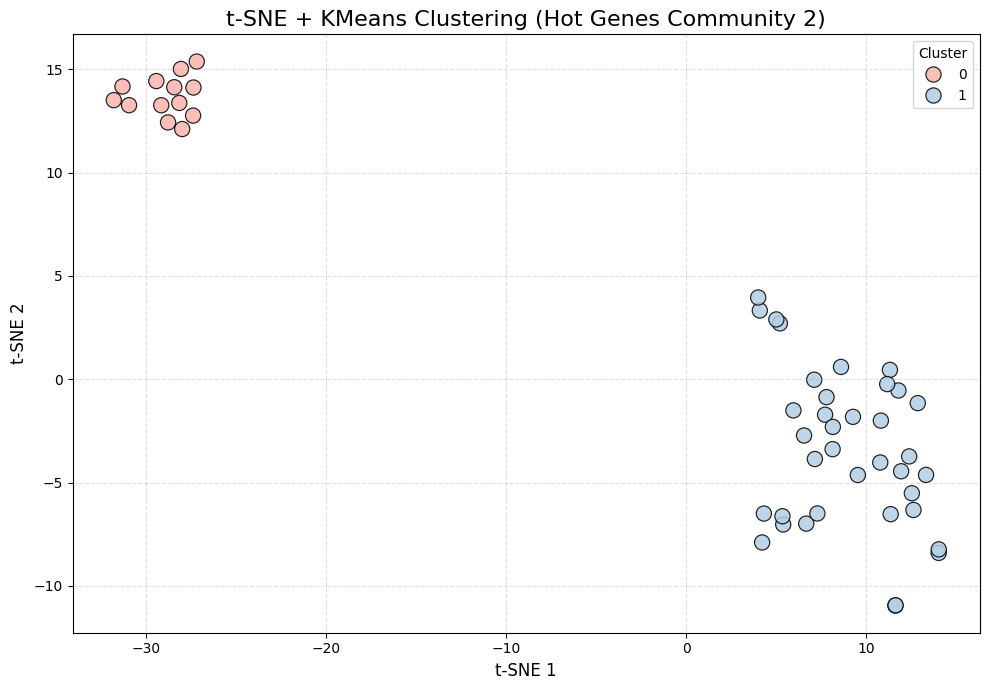

In [106]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE
tsne_2 = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_results_2 = tsne_2.fit_transform(X_2_T)

# KMeans
kmeans_2 = KMeans(n_clusters=2, random_state=42)
cluster_labels_2 = kmeans_all.fit_predict(tsne_results_2)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results_2[:, 0],
    y=tsne_results_2[:, 1],
    hue=cluster_labels_2,
    palette="Pastel1",
    s=120,              # Aumenta dimensione pallini
    edgecolor="black",  # Optional: bordo per maggiore contrasto
    alpha=0.85
)

plt.title("t-SNE + KMeans Clustering (Hot Genes Community 2)", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



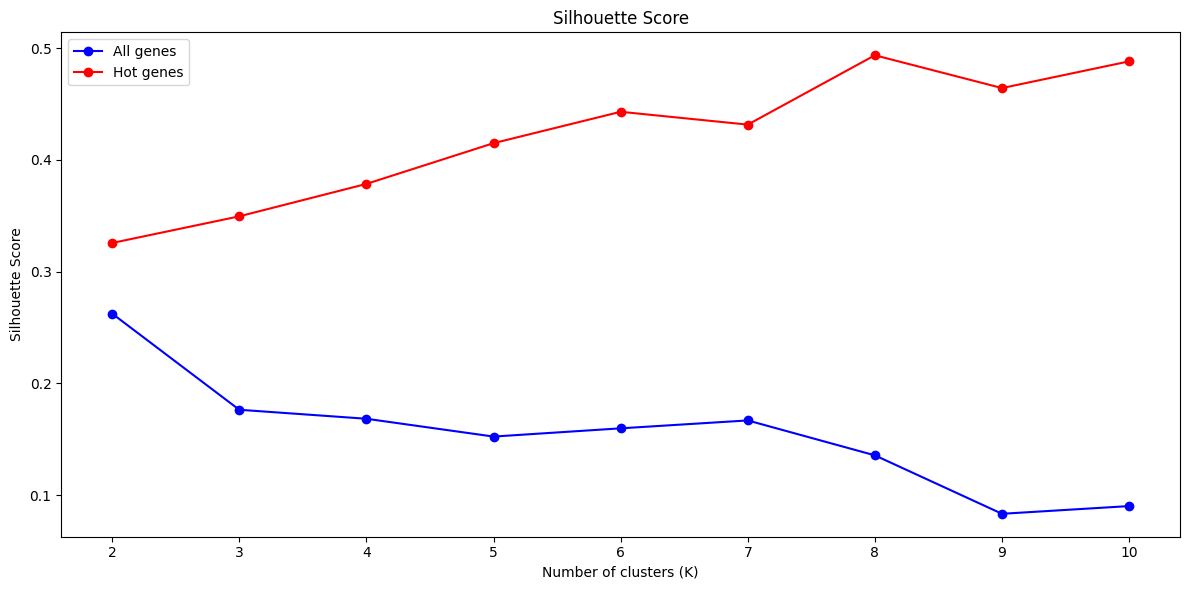

In [110]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Funzione per calcolare il Silhouette Score per diversi valori di K
def find_best_k_silhouette(X, max_k=10):
    silhouette_scores = []

    # Prova K-Means per diversi valori di K
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans_labels = kmeans.fit_predict(X)

        # Calcola il Silhouette Score
        silhouette_avg = silhouette_score(X, kmeans_labels)
        silhouette_scores.append(silhouette_avg)

    return silhouette_scores

# Calcolare il Silhouette Score per i dati con tutti i geni
silhouette_all = find_best_k_silhouette(X_all_T, max_k=10)

# Calcolare il Silhouette Score per i dati con solo i geni hotzone
silhouette_hotzone = find_best_k_silhouette(X_hot_T, max_k=10)

# Plot del Silhouette Score
plt.figure(figsize=(12, 6))

# Plot per tutti i geni
plt.plot(range(2, 11), silhouette_all, marker='o', color='blue', label="All genes")

# Plot per solo i geni hotzone
plt.plot(range(2, 11), silhouette_hotzone, marker='o', color='red', label="Hot genes")

plt.title('Silhouette Score')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()

plt.tight_layout()
plt.show()


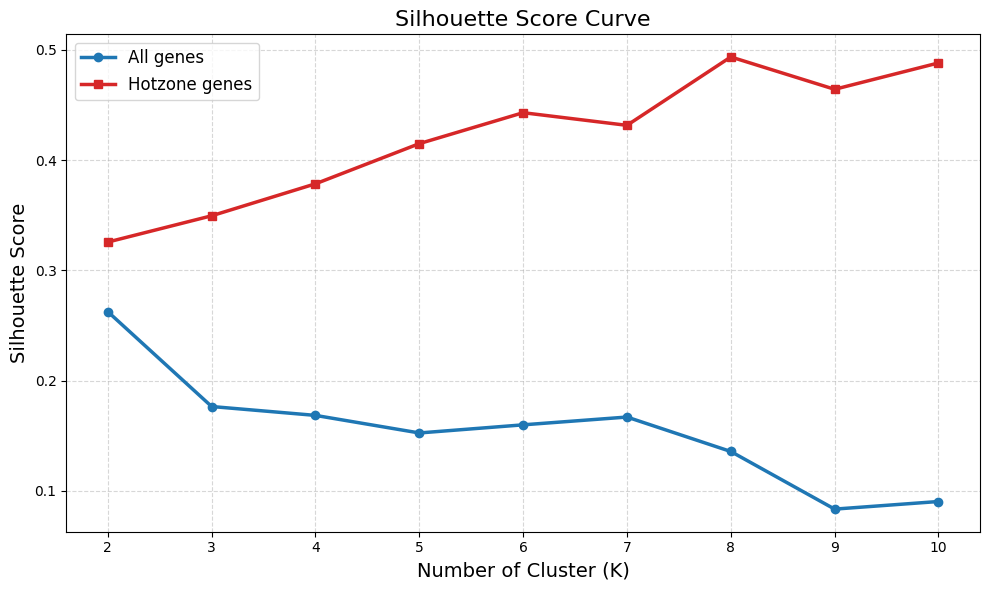

In [111]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Funzione per calcolare il Silhouette Score per diversi valori di K
def find_best_k_silhouette(X, max_k=10):
    silhouette_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans_labels = kmeans.fit_predict(X)
        silhouette_avg = silhouette_score(X, kmeans_labels)
        silhouette_scores.append(silhouette_avg)
    return silhouette_scores

# Calcola i Silhouette Score
silhouette_all = find_best_k_silhouette(X_all_T, max_k=10)
silhouette_hotzone = find_best_k_silhouette(X_hot_T, max_k=10)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_all, marker='o', color='#1f77b4', linewidth=2.5, label="All genes")
plt.plot(range(2, 11), silhouette_hotzone, marker='s', color='#d62728', linewidth=2.5, label="Hotzone genes")

# Miglioramenti estetici
plt.title('Silhouette Score Curve', fontsize=16)
plt.xlabel('Number of Cluster (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.xticks(range(2, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=12)
plt.tight_layout()
plt.show()


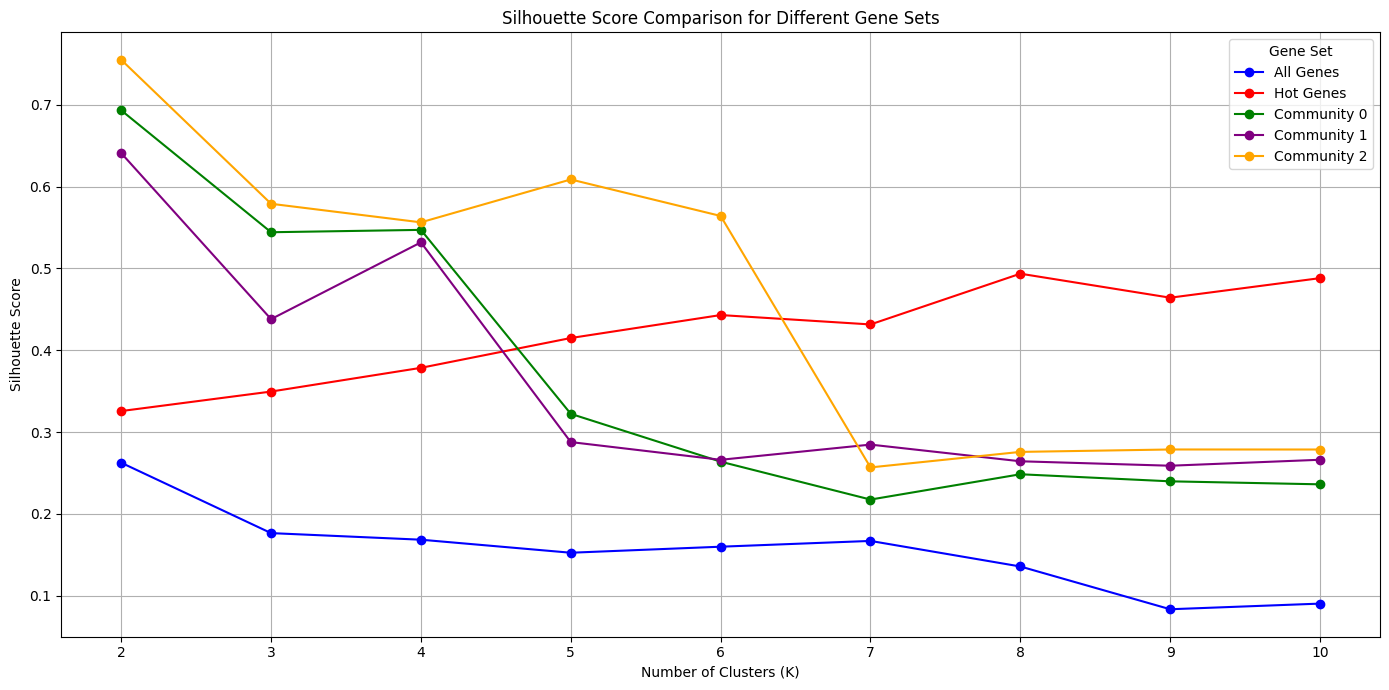

In [112]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Funzione per calcolare il Silhouette Score per diversi valori di K
def find_best_k_silhouette(X, max_k=10):
    silhouette_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
    return silhouette_scores

# Calcola Silhouette Score per ogni dataset
silhouette_all = find_best_k_silhouette(X_all_T, max_k=10)
silhouette_hot = find_best_k_silhouette(X_hot_T, max_k=10)
silhouette_0 = find_best_k_silhouette(X_0_T, max_k=10)
silhouette_1 = find_best_k_silhouette(X_1_T, max_k=10)
silhouette_2 = find_best_k_silhouette(X_2_T, max_k=10)

# Plot
plt.figure(figsize=(14, 7))
k_range = range(2, 11)

plt.plot(k_range, silhouette_all, marker='o', label='All Genes', color='blue')
plt.plot(k_range, silhouette_hot, marker='o', label='Hot Genes', color='red')
plt.plot(k_range, silhouette_0, marker='o', label='Community 0', color='green')
plt.plot(k_range, silhouette_1, marker='o', label='Community 1', color='purple')
plt.plot(k_range, silhouette_2, marker='o', label='Community 2', color='orange')

plt.title('Silhouette Score Comparison for Different Gene Sets')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend(title="Gene Set")
plt.grid(True)
plt.tight_layout()
plt.show()


In [115]:
import pandas as pd
import plotly.graph_objects as go

# Lista di colori brillanti e distinti (fino a 21)
distinct_colors = [
    "rgb(230, 25, 75)", "rgb(60, 180, 75)", "rgb(255, 225, 25)", "rgb(0, 130, 200)", "rgb(245, 130, 48)",
    "rgb(145, 30, 180)", "rgb(70, 240, 240)", "rgb(240, 50, 230)", "rgb(210, 245, 60)", "rgb(250, 190, 190)",
    "rgb(0, 128, 128)", "rgb(230, 190, 255)", "rgb(170, 110, 40)", "rgb(255, 250, 200)", "rgb(128, 0, 0)",
    "rgb(170, 255, 195)", "rgb(0, 0, 128)", "rgb(128, 128, 0)", "rgb(255, 215, 180)", "rgb(128, 64, 0)",
    "rgb(255, 100, 255)"
]

# Create DataFrame from cluster label arrays
df_clusters = pd.DataFrame({
    'All Genes': cluster_labels_all,
    'Hot Genes': cluster_labels_hot,
    'Community 0': cluster_labels_0,
    'Community 1': cluster_labels_1,
    'Community 2': cluster_labels_2
})

# Build labels
label_list = []
label_color = {}
color_index = 0
for col in df_clusters.columns:
    clusters = df_clusters[col].unique()
    for c in clusters:
        label = f"{col}: Cluster {c}"
        label_list.append(label)
        label_color[label] = distinct_colors[color_index % len(distinct_colors)]
        color_index += 1
label_list = list(dict.fromkeys(label_list))  # Remove duplicates

# Map labels to indices
label_to_index = {label: i for i, label in enumerate(label_list)}

# Build source, target, value, link colors
source = []
target = []
value = []
link_colors = []

for i in range(len(df_clusters.columns) - 1):
    col1 = df_clusters.columns[i]
    col2 = df_clusters.columns[i + 1]
    grouped = df_clusters.groupby([col1, col2]).size().reset_index(name='count')
    for _, row in grouped.iterrows():
        src_label = f"{col1}: Cluster {row[col1]}"
        tgt_label = f"{col2}: Cluster {row[col2]}"
        source.append(label_to_index[src_label])
        target.append(label_to_index[tgt_label])
        value.append(row['count'])

        # Create rgba color with transparency from the source node color
        base_rgb = label_color[src_label]
        rgba_color = base_rgb.replace("rgb", "rgba").replace(")", ", 0.4)")
        link_colors.append(rgba_color)

# Sankey diagram
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=15,
        thickness=25,
        line=dict(color="gray", width=0.5),
        label=label_list,
        color=[label_color[label] for label in label_list],
        hovertemplate='Cluster: %{label}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='From %{source.label} to %{target.label}<br>Count: %{value}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="Sankey Diagram: Comparison of Clustering Assignments Across Gene Groups",
    font=dict(size=12, color='black'),
    height=700,
    width=1100,
    margin=dict(l=10, r=10, t=40, b=10),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title_x=0.5
)

fig.show()


**Valido valutando comportamento random**

In [116]:
genes = pd.unique(df[['gene', 'tf']].values.ravel()).tolist()
len(genes)

359

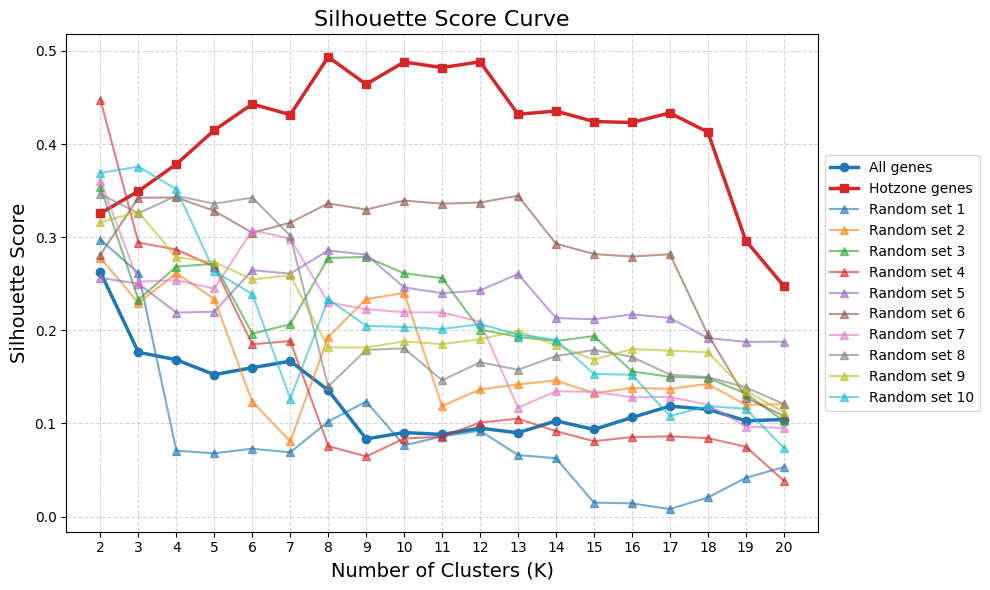

In [117]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Function to compute silhouette scores for a range of K values
def find_best_k_silhouette(X, max_k=20):
    silhouette_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
    return silhouette_scores

# Sample columns
sample_cols = [col for col in df.columns if col.startswith('Sample_')]

# All Genes -> Già sopra
X_all = df[sample_cols].values
X_all_T = X_all.T


# Hotzone Genes -> Già sopra
X_hot = filtered_df[sample_cols].values
X_hot_T = X_hot.T



# Compute silhouette scores for All and Hotzone genes
silhouette_all = find_best_k_silhouette(X_all_T, max_k=20)
silhouette_hotzone = find_best_k_silhouette(X_hot_T, max_k=20)

# Initialize figure
plt.figure(figsize=(10, 6))

# Plot silhouette scores for All and Hotzone genes
plt.plot(range(2, 21), silhouette_all, marker='o', color='#1f77b4', linewidth=2.5, label="All genes")
plt.plot(range(2, 21), silhouette_hotzone, marker='s', color='#d62728', linewidth=2.5, label="Hotzone genes")

# Random gene sampling: 10 iterations
n_iterations = 10
n_genes = 135

for i in range(n_iterations):
    random_genes = random.sample(genes, n_genes)
    filtered_random = df[df['tf'].isin(random_genes) & df['gene'].isin(random_genes)]

    if filtered_random.empty:
        continue

    X_rand = filtered_random[sample_cols].values
    X_rand_T = X_rand.T


    silhouette_rand = find_best_k_silhouette(X_rand_T, max_k=20)
    plt.plot(range(2, 21), silhouette_rand, linewidth=1.5, marker='^', alpha=0.6, label=f"Random set {i+1}")

# Final plot adjustments
plt.title('Silhouette Score Curve', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.xticks(range(2, 21))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
